# __New PROTACSplitter__


In [1]:
#We discussed to reapply the model to predict PROTACs from PROTAC DB as to identify the E3s it doesn't know. The confusion matrix for test E3 set show that it very likely to predict the E3 as POI


#Plans:

# Testsets 2 unknown substructures

#Make a code to calculate the variation between different initializations of the models



# Import packages

In [2]:
# Import packages
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
import os
import pickle
import random
from random import randint
import copy
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker
import statistics
from statistics import median
from tqdm import tqdm
import networkx as nx
from datetime import datetime
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import DataStructs
from rdkit.Chem import rdmolops
from torch_geometric.utils import from_smiles
from torch_geometric.data import Data, Dataset, InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (GraphConv, GCNConv, GATConv, GINConv, SAGEConv, 
                                TransformerConv, GINEConv, BatchNorm, GraphNorm, 
                                MeanSubtractionNorm, SAGPooling, ASAPooling)
import optuna
from contextlib import nullcontext
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, precision_score, recall_score, jaccard_score, roc_auc_score



# Import custom functions
from all_functions import (get_boundary_labels, process_predicted_boundaries_to_substructure_labels, 
                           remove_stereo, process_boundaries_to_substructure_labels, 
                           boundary_ligand_nodes_v2, make_graph_with_pos, 
                           get_substructure_smiles_function, MaxCommonSubstructure_maxatoms, 
                           process_predicted_nodes_to_substructure_labels, substructure_split_sort, 
                           prepare_data_set, mol_to_simple_graph, graph_descriptor, 
                           get_girvan_newman_encoding, find_connected_ring_systems, 
                           get_components_from_ring_systems, get_murcko_bonds, 
                           find_intercomponent_bonds, get_boundary_bonds, get_boundary_bonds_v2, 
                           format_tuple_bonds_to_COO, get_bond_labels, find_non_ring_bonds, 
                           get_substructure_smiles_function_v2, compute_countMorgFP, 
                           draw_molecule_with_highlighted_atoms, draw_molecule_with_highlighted_bonds,  
                           draw_molecule_with_colored_bonds,
                           get_all_splits_from_all_splittable_bonds, get_boundarybond_labels, 
                           generate_protacs)

/home/knkn308/.conda/envs/env-protac-toolkit/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
pd.set_option('display.max_columns', 1000, 'display.width', 2000, 'display.max_colwidth', 100)


# Define Model

In [4]:
#GCNConv worked well before, with a validation accuracy of around 0.93
#GraphConv: maybe converges faster?



class PROTACSplitter_2(torch.nn.Module):
    def __init__(self, init_params):
        super(PROTACSplitter_2, self).__init__()

        # Assign basic parameters from init_params for existing configurations
        self.assign_basic_parameters(init_params)
        
        # Activation function setup
        self.set_activation_function(init_params['activationfunction'])
        self.last_activation_function = init_params.get("last_activation_function", None)
        
        # Layer mapping for GNN layers
        self.layer_map = self.get_layer_map()

        # Initialize GNN layers based on configurations
        self.define_gnn_layers(init_params)

        if self.model_type == "link_pred":
            # Initialize output layers based on configurations
            self.output_layers = self.initialize_output_layers(init_params.get('output_layer_config', []))
            
            # NEW: Initialize boundary layers based on configurations
            self.boundary_layers = self.initialize_output_layers(init_params.get('boundary_layer_config', []))
        
        # Define normalization layers if applicable
        self.define_normalization_layers()
        
        # Additional model configurations
        self.configure_additional_model_parameters(init_params)
        
        # Softmax for boundary bond probabilities
        self.softmax_for_boundary_bond_probs = nn.Softmax(dim=0)


    def define_gnn_layers(self, init_params):
        self.layers = torch.nn.ModuleList()

        if self.gnn_layer_type == "GINConv":              
            raise ValueError("OBS! GINConv not implmented yet. It seems to use an MLP as input")
        else:
            self.GNNLayer = self.layer_map[self.gnn_layer_type]


            # First layer
        if self.use_edge_information:
            if self.gnn_layer_type == 'TransformerConv':
                self.layers.append(self.GNNLayer(init_params['node_feature_dim'], self.layer_dims[0], edge_dim=3, beta=self.TransformerConvBeta, heads=self.TransformerConvHeads, dropout=self.TransformerConvDropout))
            else:
                self.layers.append(self.GNNLayer(init_params['node_feature_dim'], self.layer_dims[0], edge_dim=3))
        else:
            self.layers.append(self.GNNLayer(init_params['node_feature_dim'], self.layer_dims[0]))


            # Hidden layers
        for i in range(0, len(self.layer_dims)-1):
            if self.gnn_layer_type == 'TransformerConv':
                self.layers.append(self.GNNLayer(self.layer_dims[i]*self.TransformerConvHeads, self.layer_dims[i+1], beta=self.TransformerConvBeta, heads=self.TransformerConvHeads, dropout=self.TransformerConvDropout))
            else:
                self.layers.append(self.GNNLayer(self.layer_dims[i], self.layer_dims[i+1]))

        

    def assign_basic_parameters(self, init_params):
        self.use_edge_information = init_params["use_edge_information"]
        self.use_jumping_knowledge = init_params['use_jumping_knowledge']
        self.use_skip_connections = init_params["use_skip_connections"]
        self.use_batch_normalization = init_params["use_batch_normalization"]
        self.use_graph_normalization = init_params["use_graph_normalization"]
        self.use_MeanSubtractionNorm = init_params["use_MeanSubtractionNorm"]
        self.dropout = init_params["dropout_rate"]
        self.regularization_types = init_params['regularization_types']
        self.gnn_layer_type = init_params['gnn_layer_type']
        self.model_type = init_params['model_type']
        self.layer_dims = init_params['layer_dims']
        self.final_layer_dim = init_params['final_layer_dim']
        self.layer_dims[-1] = self.final_layer_dim
        self.TransformerConvBeta = init_params['TransformerConvBeta']
        self.TransformerConvHeads = init_params['TransformerConvHeads']
        self.TransformerConvDropout = init_params['TransformerConvDropout']
        self.num_predicted_classes = init_params['num_predicted_classes']
        self.device = init_params['device']
        self.poi_label = 0
        self.e3_label = 2

    def set_activation_function(self, activation_type):
        if activation_type == "relu":
            self.ActFun = F.relu
        elif activation_type == "lrelu":
            self.ActFun = nn.LeakyReLU()
        # Extendable for other activation functions

    def get_layer_map(self):
        layer_map = {
            'GraphConv': GraphConv,
            'GCNConv': GCNConv,
            'GATConv': GATConv,
            'SAGEConv': SAGEConv,
            'TransformerConv': TransformerConv,
            # Placeholder for AttentiveFP if available and others
        }
        if 'GINConv' in layer_map:
            raise ValueError("OBS! GINConv not implemented yet. It seems to use an MLP as input")
        return layer_map

    def define_normalization_layers(self):
        if self.use_batch_normalization:
            self.batch_norm_layers = torch.nn.ModuleList([BatchNorm(dim) for dim in self.layer_dims[:-1]])
        if self.use_graph_normalization:
            self.graph_norm_layers = torch.nn.ModuleList([GraphNorm(dim) for dim in self.layer_dims[:-1]])
        if self.use_MeanSubtractionNorm:
            self.MeanSubtractionNorm_layers = torch.nn.ModuleList([MeanSubtractionNorm() for dim in self.layer_dims[:-1]])
   

    def initialize_output_layers(self, layer_configs):
        output_layers = torch.nn.ModuleDict()  
        for idx, config in enumerate(layer_configs):
            layer_type = config.get('type', 'linear')  
            layer_key_prefix = f"{layer_type}_{idx}"  

            depth = config.get('depth', 1)  # Default depth is 1
            base_in_features = self.layer_dims[-1] if config['in_features'] == -1 else config['in_features']

            in_features = base_in_features
            if 'global' in layer_type:
                in_features += base_in_features
            if self.gnn_layer_type == 'TransformerConv' and idx == 0:  # For first layer with TransformerConv
                in_features += base_in_features * (self.TransformerConvHeads - 1)
            if 'symmetric' in layer_type:
                in_features += base_in_features
            
            for d in range(depth):
                layer_key = f"{layer_key_prefix}_{d}"  # Unique key for each layer in depth
                if d == depth - 1:  # Last layer
                    out_features = config['out_features']
                else:
                    out_features = config.get('intermediate_features', base_in_features)
                layer = torch.nn.Linear(in_features, out_features)
                in_features = out_features
                
                output_layers[layer_key] = layer

        return output_layers
    
    def configure_additional_model_parameters(self, init_params):
        self.pooling_layers = torch.nn.ModuleList()
        self.num_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        self.states = []
        

    


    def process_gnnlayers(self, z, edge_index, edge_attr):
        skip_z = [] if self.use_skip_connections else None
        
        # Apply GNN layers
        for layer_idx, layer in enumerate(self.layers):
            
            if self.use_edge_information and layer_idx == 0:
                z = layer(z, edge_index, edge_attr=edge_attr)
            else: 
                z = layer(z, edge_index)
                
            if self.use_batch_normalization and layer_idx < len(self.batch_norm_layers):
                z = self.batch_norm_layers[layer_idx](z)
            if self.use_graph_normalization and layer_idx < len(self.graph_norm_layers):
                z = self.graph_norm_layers[layer_idx](z)
            if self.use_MeanSubtractionNorm and layer_idx < len(self.MeanSubtractionNorm_layers):
                z = self.MeanSubtractionNorm_layers[layer_idx](z)

            z = self.ActFun(z)
            
            if self.use_skip_connections:
                skip_z += [z]

            z = F.dropout(z, p=self.dropout, training=self.training)
           
            if self.use_skip_connections:
                if len(skip_z)>1:
                    if z.size() == skip_z[-2].size():
                        z = z + skip_z[-2]

        return z

    def process_outlayers(self, input, layers):
        "Process input through a sequence of layers."
        for idx, (layer_key, layer) in enumerate(layers.items()):  # Apply all but the last layer with activation
            if idx == len(layers)-1:
                #last layer has been defined. Skip ActFun and dropout
                break
            if idx == 0 and 'symmetric' in layer_key:
                input = layer(input[0]) + layer(input[1])
            else:
                input = layer(input)
            input = self.ActFun(input)
            # Apply dropout between intermediate layers if enabled
            #input = F.dropout(input, p=self.dropout, training=self.training)
        # No activation after the last layer
        return layer(input)
    

    def forward(self, batch, edges_to_predict = None):
        z, edge_index = batch["x"], batch["edge_index"]

        if self.use_edge_information:
            edge_attr = batch["edge_attr"]
        else:
            edge_attr = None

        z = self.process_gnnlayers(z, edge_index, edge_attr)

        if self.model_type == "link_pred":
            z_edges_0 = torch.cat((z[edges_to_predict[:,0]], z[edges_to_predict[:,1]]), dim=1) if edges_to_predict is not None else None
            z_edges_1 = torch.cat((z[edges_to_predict[:,1]], z[edges_to_predict[:,0]]), dim=1) if edges_to_predict is not None else None
            z_edges = (z_edges_0, z_edges_1)
        
            if self.model_type == "link_pred" and edges_to_predict is None:
                raise ValueError("edges_to_predict was is None")

            # Boundary location pred
            y_location = self.process_outlayers(z_edges, self.boundary_layers)

            # Boundary type pred
            y_type = self.process_outlayers(z if edges_to_predict is None else z_edges, self.output_layers)
        
        elif self.model_type == "node_pred":
            y_type = z
            y_location = None

        return y_type, y_location







    def get_model_type(self):
        return self.model_type



    def get_protac_data(self, protac_smiles, precompute_splits=False):
        return ProtacDataset(protac_input=protac_smiles, 
                             mode="predict", 
                             model_type=self.model_type,
                             node_descriptors=self.node_descriptors, 
                             graph_descriptor_list=self.graph_descriptor_list,
                             precompute_splits = precompute_splits) #as smiles or list of smiles is fed, and not Dataframe with POI and E3 smiles, only mode="predict" can be used
        


    def train_model(self, train_params):
        
        datasets_dict = train_params['datasets_dict']
        criterion = train_params['criterion']
        lr = train_params['lr']
        optimizer = train_params['optimizer'](self.parameters(), lr=lr)
        epochs = train_params['epochs']
        max_epochs = train_params['max_epochs']

        val_early_stopping = train_params['val_early_stopping']
        median_over_n_val_losses = train_params['median_over_n_val_losses']
        min_over_n_val_losses = train_params['min_over_n_val_losses']
        stop_if_val_acc_below_x_at_n_list = train_params['stop_if_val_acc_below_x_at_n_list']

        print_every_n_epochs = train_params['print_every_n_epochs']
        self.compute_pretrained_values = train_params['compute_pretrained_values']
        self.compute_rand_accuracy = train_params['compute_rand_accuracy']

        fp_function = train_params['fp_function']
        e3_database_fps = fp_function(train_params['e3_library'])
        poi_database_fps = fp_function(train_params['poi_library'])
        self.use_new_postprocessing_algorithm = train_params['use_new_postprocessing_algorithm']
        
        if "Train" in datasets_dict:
            self.train_set_name = "Train"
        elif "train_CV" in datasets_dict:
            self.train_set_name = "train_CV"
        else:
            raise ValueError("No dataset named 'Train' or 'train_CV'!")
    
        if self.compute_rand_accuracy is True:
            datasets_dict["Dummy"] = datasets_dict[self.train_set_name] #do random predictions on training protacs
        
        
        self.training = False


        if not hasattr(self, 'measures'):
            self.measures = {'loss': {}, 
                                'boundary_bond_probs': {},
                                'metrics': {},
                                'validity': {}
                                }

        self.node_descriptors = None #training_data.node_descriptors
        self.graph_descriptor_list = None #training_data.graph_descriptor_list

        self.structure_types_template = {"PROTAC": [], "POI": [], "LINKER": [], "E3": [], "LIGANDS": []}
        

        self.total_nodes = {}

        
           
        loaders = {}
        for i, (name, dataset) in enumerate(datasets_dict.items()):

            #get dataloaders
            if name in [self.train_set_name, "Dummy"]:
                shuffle = True
            else:
                shuffle = False
            
            if name == "Dummy":
                batch_size = 1
            else:
                batch_size = train_params['batch_size']

            loaders[name] = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
        
            

            #metrics for dataset
            for key in self.measures.keys():
                self.measures[key][name] = []
 
            #make sure same node_descriptors and graph_descriptor_list for all datasets
            if self.node_descriptors is None:
                self.node_descriptors = dataset.node_descriptors
            elif self.node_descriptors != dataset.node_descriptors:
                raise ValueError(f"self.node_descriptors: {self.node_descriptors} != dataset.node_descriptors ({name}): {dataset.node_descriptors}")
            if self.graph_descriptor_list is None:
                self.graph_descriptor_list = dataset.graph_descriptor_list
            elif self.graph_descriptor_list != dataset.graph_descriptor_list:
                raise ValueError(f"self.graph_descriptor_list: {self.graph_descriptor_list} != dataset.graph_descriptor_list ({name}): {dataset.graph_descriptor_list}")

            self.total_nodes[name] = None 

        
        #Store this in model to simplify code and skip recalculating on every epoch (slow) 
        self.total_train_nodes = None
        self.total_val_nodes = None
        num_testsets = max([0, len(datasets_dict)-2])
        self.total_tests_nodes = [None for _ in range(num_testsets)] 


        # Training loop
        self.epoch = 0
        delta_val_criteria = 1
        self.have_computed_pretrained_values = False
        while self.epoch < max_epochs and ((self.epoch < epochs and val_early_stopping is False) or (val_early_stopping and delta_val_criteria >= 0)):
            for i, (name, dataset) in enumerate(datasets_dict.items()):
                if name == "Dummy" and self.compute_rand_accuracy is False:
                    continue

                if i == 0:
                    train_or_eval = "train"
                elif i > 1:
                    train_or_eval = "eval"
                if self.compute_pretrained_values and self.have_computed_pretrained_values is False:
                    train_or_eval = "eval"
                    self.have_computed_pretrained_values = True
                    self.epoch =- 1  

                epoch_output = self._train_or_evaluate_epoch(name=name, 
                                                                 loader=loaders[name], 
                                                                 criterion=criterion, 
                                                                 optimizer=optimizer,
                                                                 train_or_eval=train_or_eval, 
                                                                 e3_database_fps=e3_database_fps, 
                                                                 poi_database_fps=poi_database_fps, 
                                                                 fp_function=fp_function)

                self.measures['loss'][name].append(epoch_output["average_loss"])
                self.measures['metrics'][name].append(epoch_output["metrics"])
                validity_percentages = {key: count/len(dataset) for key, count in epoch_output["validity"].items()} #Count => percentage
                self.measures['validity'][name].append(validity_percentages)

            #save current parameters
            self.states.append(self.state_dict())


            self.epoch += 1


            # Print metrics every n epochs
            if self.epoch % print_every_n_epochs == 0:
                self._print_epoch_metrics()


            #Early stopping
            if val_early_stopping:
                delta_val_criteria = self._early_stopping(max_epochs, 
                                                          median_over_n_val_losses, 
                                                          stop_if_val_acc_below_x_at_n_list, 
                                                          min_over_n_val_losses)

        return self.measures



    def _train_or_evaluate_epoch(self, name, loader, criterion, train_or_eval, optimizer=None, e3_database_fps=None, poi_database_fps=None, fp_function = None, max_num_rand_pred_protacs=200, get_loss = True):        
        total_loss = 0
        boundary_bond_probs_dataset = []
        count_rand_pred = 0

        metrics_template = {'Accuracy': [], 'FP_FN': {}, 'Precision': [], 'Recall': [], "F1": [], "Specificity": [], "MCC": [], 'Jaccard': []}
        validity = {'VALID SPLIT': 0, 'POI SMILES': 0, 'LINKER SMILES': 0, 'E3 SMILES': 0}
        flip_counter = 0

        metrics = {
                        "model": {"PROTAC": copy.deepcopy(metrics_template), 
                                   "POI": copy.deepcopy(metrics_template), 
                                   "LINKER": copy.deepcopy(metrics_template), 
                                   "E3": copy.deepcopy(metrics_template), 
                                   "LIGANDS": copy.deepcopy(metrics_template) }, 
                        
                        "model+check_library": {"PROTAC": copy.deepcopy(metrics_template), 
                                                "POI": copy.deepcopy(metrics_template), 
                                                "LINKER": copy.deepcopy(metrics_template), 
                                                "E3": copy.deepcopy(metrics_template), 
                                                "LIGANDS": copy.deepcopy(metrics_template) }
                        }
        
        if self.total_nodes[name] is None:
            total_nodes = 0
            compute_total_nodes = True
        else:
            total_nodes = self.total_nodes[name]
            compute_total_nodes = False

        if train_or_eval == "train":
            self.training = True #for dropout
            self.train()
        elif train_or_eval == "eval":
            self.eval()
            
        with nullcontext() if train_or_eval == "train" else torch.no_grad(): 
            for batch in loader:
                batch = batch.to(self.device)


                if name == "Dummy":
                    if count_rand_pred>max_num_rand_pred_protacs:
                        break
                    else:
                        count_rand_pred += len(batch)
                    randomize_y = True
                else:
                    randomize_y = False

                
                if train_or_eval == "train":
                    optimizer.zero_grad()  # Reset gradients for next batch

                y_type, y_location, predictions_and_prob, boundary_bond_probs_dataset = self.batch_to_output_and_classpredictions(batch=batch, e3_database_fps=e3_database_fps, poi_database_fps=poi_database_fps, fp_function=fp_function, randomize_y=randomize_y)
                metrics, validity, flip_counter = self._count_correct_and_total_nodes(batch=batch, predictions_and_prob=predictions_and_prob, metrics=metrics, validity=validity, flip_counter=flip_counter, name=name)

                if get_loss:
                    loss = self._compute_loss(criterion, batch, y_type, y_location)
                    total_loss += loss.item() 

                if train_or_eval == "train":
                    loss.backward() 
                    optimizer.step()  

                if compute_total_nodes:
                    total_nodes += batch.num_nodes

        # Store total nodes for future epochs
        if compute_total_nodes: 
            self.total_nodes[name] = total_nodes

        #Maksure to set to false for dropout
        if self.training:
            self.training = False

        output = {}
        output["metrics"] = metrics
        output["average_loss"] = total_loss / total_nodes 
        output["boundary_bond_probs_dataset"] = boundary_bond_probs_dataset
        output["validity"] = validity
        output["flip_counter"] = flip_counter

        return output

    def _count_correct_and_total_nodes(self, batch, predictions_and_prob, metrics, validity, flip_counter, name):
        true_protac_nodes_dataset = batch["substructure_labels"].cpu()

        pred_protac_nodes_dataset_dict = {}
        for accuracy_origin in predictions_and_prob.keys():
            pred_protac_nodes_dataset_dict[accuracy_origin] = predictions_and_prob[accuracy_origin][0].cpu()
        
        for protac_idx in range(len(batch)):
            start_idx = batch.ptr[protac_idx]
            end_idx = batch.ptr[protac_idx+1]      

            true_protac_nodes = true_protac_nodes_dataset[start_idx: end_idx]

            protac_smiles = batch[protac_idx].smiles
            substructures_smi, substructure_smi_with_attachmentpoints = get_substructure_smiles_function_v2(protac_smiles, 
                                                                                                        true_protac_nodes, 
                                                                                                        boundary_bonds =  (None, None))
            for substructure_key, substructure_smiles in substructures_smi.items():
                if substructure_smiles != None:
                    validity[substructure_key] += 1
                elif True:
                    print(f"Found invalid smiles for {substructure_key} in PROTAC SMILES: {protac_smiles}" )
                    print("Predicted subtrsuctures:")
                    print(substructures_smi)
                    print(substructure_smi_with_attachmentpoints)
                    substructures_smi, substructure_smi_with_attachmentpoints = get_substructure_smiles_function_v2(protac_smiles, 
                                                                                                        true_protac_nodes, 
                                                                                                        boundary_bonds =  (None, None))
                    if name == "Dummy":
                        randomize_y = True
                    else:
                        randomize_y = False
                    y_typex, y_locationx, predictions_and_probx, boundary_bond_probs_datasetx = self.batch_to_output_and_classpredictions(batch=batch, 
                                                                                e3_database_fps=None, 
                                                                                poi_database_fps=None, 
                                                                                fp_function=compute_countMorgFP, 
                                                                                randomize_y=randomize_y)
                    print(y_typex)
                    print(y_locationx)
                    print(predictions_and_probx)



            
            if None not in list(substructure_smi_with_attachmentpoints.values()):
                validity["VALID SPLIT"] += 1


            true_poi_nodes_bool = 0 == true_protac_nodes
            true_linker_nodes_bool = 1 == true_protac_nodes
            true_e3_nodes_bool = 2 == true_protac_nodes
            true_ligand_nodes_bool = (true_poi_nodes_bool) | (true_e3_nodes_bool)

            for accuracy_origin in metrics.keys():
                
                pred_protac_nodes = pred_protac_nodes_dataset_dict[accuracy_origin][start_idx: end_idx]
        
                pred_poi_nodes_bool = 0 == pred_protac_nodes
                pred_linker_nodes_bool = 1 == pred_protac_nodes
                pred_e3_nodes_bool = 2 == pred_protac_nodes
                pred_ligand_nodes_bool = pred_poi_nodes_bool | pred_e3_nodes_bool

                for structure_type in metrics[accuracy_origin].keys():

                    if structure_type == "PROTAC":
                        true_structure_nodes = true_protac_nodes
                        pred_structure_nodes = pred_protac_nodes
                    elif structure_type == "POI":
                        true_structure_nodes = true_poi_nodes_bool
                        pred_structure_nodes = pred_poi_nodes_bool
                    elif structure_type == "LINKER":
                        true_structure_nodes = true_linker_nodes_bool
                        pred_structure_nodes = pred_linker_nodes_bool
                    elif structure_type == "E3":
                        true_structure_nodes = true_e3_nodes_bool
                        pred_structure_nodes = pred_e3_nodes_bool
                    elif structure_type == "LIGANDS":
                        true_structure_nodes = true_ligand_nodes_bool
                        pred_structure_nodes = pred_ligand_nodes_bool
                    try:
                        metrics = self._calc_eval_metrics(true_structure_nodes=true_structure_nodes,
                                                                pred_structure_nodes=pred_structure_nodes, 
                                                                metrics = metrics,
                                                                accuracy_origin = accuracy_origin,
                                                                structure_type = structure_type)
                    except:
                        print(structure_type)
                        print(f'true_structure_nodes: {true_structure_nodes}')
                        print(f'pred_structure_nodes: {pred_structure_nodes}')
                        raise ValueError("_calc_eval_metrics failed")
                
                if accuracy_origin == "model":
                    if metrics["model"]["Accuracy"]["LIGANDS"] > metrics["model"]["Accuracy"]["PROTAC"]:
                        flip_counter += 1

        return metrics, validity, flip_counter

       

    def _calc_eval_metrics(self, true_structure_nodes, pred_structure_nodes, metrics, accuracy_origin, structure_type):
        total_tmp = true_structure_nodes.size(0)
        
        FalsePositive_FalseNegative = (true_structure_nodes != pred_structure_nodes).sum().item()
        if FalsePositive_FalseNegative not in metrics[accuracy_origin][structure_type]["FP_FN"]:
            metrics[accuracy_origin][structure_type]["FP_FN"][FalsePositive_FalseNegative] = 0
        metrics[accuracy_origin][structure_type]["FP_FN"][FalsePositive_FalseNegative] += 1

        TruePositive_TrueNegative = total_tmp - FalsePositive_FalseNegative
        accuracy = TruePositive_TrueNegative / total_tmp
        metrics[accuracy_origin][structure_type]["Accuracy"].append(accuracy)
        

        if structure_type != "PROTAC":
            average = "binary"
            precision = precision_score(y_true=true_structure_nodes, y_pred=pred_structure_nodes, average=average)
            recall = recall_score(y_true=true_structure_nodes, y_pred=pred_structure_nodes, average=average)
            f1 = f1_score(y_true=true_structure_nodes, y_pred=pred_structure_nodes, average=average)

            metrics[accuracy_origin][structure_type]["Precision"].append(precision)
            metrics[accuracy_origin][structure_type]["Recall"].append(recall)
            metrics[accuracy_origin][structure_type]["F1"].append(f1)

            
        return metrics
    

    def _print_epoch_metrics(self, epoch = None):


        if epoch is None or epoch == -1:
            epoch = self.epoch
        index = epoch - 1 + int(self.compute_pretrained_values)


        print(f"Epoch {epoch} Metrics:")

        printout_dict = {}
        for dataset_name in self.measures['metrics'].keys():
            for accuracy_origin in self.measures['metrics'][dataset_name][index].keys():
                for structure_type in self.measures['metrics'][dataset_name][index][accuracy_origin].keys():
                    for metric_type in self.measures['metrics'][dataset_name][index][accuracy_origin][structure_type].keys():
                        if metric_type == "FP_FN":
                            continue
                        column_name = f'{accuracy_origin}_{structure_type}_{metric_type}'
                        
                        avg_metric = avg(self.measures['metrics'][dataset_name][index][accuracy_origin][structure_type][metric_type])
                        if avg_metric is not None:
                            if column_name not in printout_dict:
                                printout_dict[column_name] = []
                            printout_dict[column_name].append(avg_metric*100)


        printout_df = pd.DataFrame(printout_dict)
        row_names = [dataset_name for dataset_name in self.measures['metrics'].keys()]
        printout_df.index = row_names
        print(printout_df.round(1))


    def _early_stopping(self, max_epochs, median_over_n_val_losses, stop_if_val_acc_below_x_at_n_list, min_over_n_val_losses):
        delta_val_criteria = 1
        stopping_cause = "Mistaken stopping - Look for error in _early_stopping()"
        if max_epochs == self.epoch:
            delta_val_criteria = -1
            stopping_cause = "Stopping: Max epoch reached"
        elif median_over_n_val_losses is not None and len(self.metrics['avg_val_loss']) >= 2*median_over_n_val_losses:
            median_last_n_to_2n_epochs = median(self.metrics['avg_val_loss'][-2*median_over_n_val_losses:-median_over_n_val_losses])
            median_last_n_epochs = median(self.metrics['avg_val_loss'][-median_over_n_val_losses:]) 
            delta_val_criteria = median_last_n_to_2n_epochs - median_last_n_epochs # continue if delta_val_criteria is positive -> validation loss is decreasing
            stopping_cause = "Early stopping: Increaing median validation loss"
        elif stop_if_val_acc_below_x_at_n_list is not None: #a list of criteria on validation accuracy - val acc must be above  val_frac_criteria   at  n_epochs
            for stop_if_val_acc_below_x_at_n_dict in stop_if_val_acc_below_x_at_n_list:
                n_epochs = stop_if_val_acc_below_x_at_n_dict['n_epochs']
                val_frac_criteria = stop_if_val_acc_below_x_at_n_dict['val_frac_criteria']
                if self.epoch >= n_epochs:
                    delta_val_criteria = self.metrics['val_accuracy'][-1] - val_frac_criteria
                    stopping_cause = f"Early stopping: Validation accuracy below {val_frac_criteria} at or after {n_epochs} epochs"
        elif min_over_n_val_losses is not None and len(self.metrics['avg_val_loss']) >= 2*min_over_n_val_losses:
            min_last_n_to_2n_epochs = min(self.metrics['avg_val_loss'][-2*min_over_n_val_losses:-min_over_n_val_losses])
            min_last_n_epochs = min(self.metrics['avg_val_loss'][-min_over_n_val_losses:]) 
            delta_val_criteria = min_last_n_to_2n_epochs - min_last_n_epochs # continue if delta_val_criteria is positive -> validation loss is decreasing
            stopping_cause = f"Early stopping: Increasing lowest validation loss (The lowest validation loss between epochs {self.epoch-2*min_over_n_val_losses} and {self.epoch-1*min_over_n_val_losses} is lower than the lowest validation loss between epochs {self.epoch-1*min_over_n_val_losses+1} and {self.epoch})"

        if delta_val_criteria < 0:
            print(stopping_cause)
        
        return delta_val_criteria


    def _predict_bond_idx(self, raw_prediction_protac):
        pred_poi_boundary_bond_idx, _, pred_e3_boundary_bond_idx = raw_prediction_protac.argmax(dim=0)

                
                
        n_highest_pred_node = 1
        if pred_poi_boundary_bond_idx == pred_e3_boundary_bond_idx:
            raw_prediction_protac_temporary = torch.clone(raw_prediction_protac)    #SLOW?   #TopK is slow
        while pred_poi_boundary_bond_idx == pred_e3_boundary_bond_idx:          
                           
            poi_pred_val = raw_prediction_protac_temporary[pred_poi_boundary_bond_idx, self.poi_label]
            e3_pred_val = raw_prediction_protac_temporary[pred_poi_boundary_bond_idx, self.e3_label]
            if e3_pred_val>poi_pred_val:
                        #overwrite the value of the POI
                raw_prediction_protac_temporary[pred_poi_boundary_bond_idx,self.poi_label] = float('-inf')  #min_vals[0, 0].item()
                        #find the index of second most likely POI 
                pred_poi_boundary_bond_idx = torch.topk(raw_prediction_protac_temporary[:,self.poi_label], k=n_highest_pred_node, dim=0).indices.tolist()[-1]
                        #get the index
                pred_poi_boundary_bond_idx, _, pred_e3_boundary_bond_idx = raw_prediction_protac_temporary.argmax(dim=0)
            else:
                raw_prediction_protac_temporary[pred_e3_boundary_bond_idx,self.e3_label] = float('-inf') #min_vals[0, 2].item() #redefine the highest E3 to the lowest value 
                pred_e3_boundary_bond_idx = torch.topk(raw_prediction_protac_temporary[:,self.e3_label], k=n_highest_pred_node, dim=0).indices.tolist()[-1]
                pred_poi_boundary_bond_idx, _, pred_e3_boundary_bond_idx = raw_prediction_protac_temporary.argmax(dim=0) #Get new highest max values (for E3)
                    
                    
            n_highest_pred_node +=1
        
        return pred_poi_boundary_bond_idx, pred_e3_boundary_bond_idx


    def _predict_node_labels_and_probabilities_for_batch(self, batch, raw_prediction, splittable_bonds_ptr = None, e3_database_fps=None, poi_database_fps=None, fp_function=None, predicted_boundary_bonds=None):
        boundary_bond_probs = []
        if self.model_type == "boundary_pred":
            class_predictions = torch.empty(size=(0,), dtype=torch.float32)
            probabilites = torch.empty(size=(0,self.num_predicted_classes), dtype=torch.float32)

            for protac_idx in range(len(batch)):
                
                protac_smiles = batch[protac_idx]["smiles"]
                start_row_idx = batch["ptr"][protac_idx].item()
                end_row_idx = batch["ptr"][protac_idx+1].item()
                raw_prediction_protac =  raw_prediction[start_row_idx:end_row_idx]  #chunck up raw_prediction into each protac
                class_prediction_protac = process_predicted_boundaries_to_substructure_labels(protac_smiles=protac_smiles, raw_boundary_prediction=raw_prediction_protac)
                probabilites_protac = F.softmax(raw_prediction_protac, dim=1)

                class_predictions = torch.cat((class_predictions, class_prediction_protac), dim=0)
                probabilites = torch.cat((probabilites, probabilites_protac), dim=0)


        elif self.model_type == "node_pred": 
            class_predictions = torch.empty(size=(0,), dtype=torch.float32) #On CPU when created
            class_predictions_checked_against_library = torch.empty(size=(0,), dtype=torch.float32) #On CPU when created
            
            probabilites = torch.empty(size=(0,), dtype=torch.float32)  #not yet implemented

            if False:
                class_predictions = raw_prediction.argmax(dim=1)
                probabilites = F.softmax(raw_prediction, dim=1)
                class_predictions_checked_against_library = class_predictions.clone()
            else:
                poi_diff_prob = raw_prediction[:,0] - raw_prediction[:,1] - raw_prediction[:,2]
                linker_diff_prob = raw_prediction[:,1] - raw_prediction[:,0] - raw_prediction[:,2]
                e3_diff_prob = raw_prediction[:,2] - raw_prediction[:,0] - raw_prediction[:,1]
                #ligand_diff_prob = -linker_diff_prob
                for protac_idx in range(len(batch)):
                    protac_data = batch[protac_idx]
                    #print(protac_data)

                    start_row_idx = batch.ptr[protac_idx]
                    end_row_idx = batch.ptr[protac_idx+1]
                    raw_prediction_protac =  raw_prediction[start_row_idx:end_row_idx]

                    protac_poi_diff_prob =  poi_diff_prob[start_row_idx:end_row_idx]
                    protac_linker_diff_prob =  linker_diff_prob[start_row_idx:end_row_idx]
                    protac_e3_diff_prob =  e3_diff_prob[start_row_idx:end_row_idx]
                    #protac_ligand_diff_prob =  ligand_diff_prob[start_row_idx:end_row_idx]

                    best_diff_prob = 0
                    best_split_idx = None
                    #print(protac_data[0])
                    for split_idx, (linker_atoms, (ligand_0_atoms, ligand_1_atoms)) in enumerate(zip(protac_data.all_possible_linker_atom_idx_for_all_protacs, protac_data.all_possible_ligands_atom_idx_for_all_protacs)):
                        #print(protac_linker_diff_prob.size())
                        #print(ligand_0_atoms)
                        #print(-protac_linker_diff_prob[ligand_0_atoms] )
                        ligand_0_diff_prob = -protac_linker_diff_prob[ligand_0_atoms]
                        ligand_1_diff_prob = -protac_linker_diff_prob[ligand_1_atoms]
                        ligands_diff_prob = ligand_0_diff_prob.sum().item() + ligand_1_diff_prob.sum().item()
                        #print(ligands_diff_prob)
                        linker_diff_prob = protac_linker_diff_prob[linker_atoms].sum().item()

                        

                        if best_diff_prob < (ligands_diff_prob + linker_diff_prob):
                            best_diff_prob = ligands_diff_prob + linker_diff_prob
                            best_split_idx = split_idx
                    
                    
                    linker_atoms = protac_data.all_possible_linker_atom_idx_for_all_protacs[best_split_idx]
                    ligand_0_atoms, ligand_1_atoms = protac_data.all_possible_ligands_atom_idx_for_all_protacs[best_split_idx]
                    score_poie3 = protac_poi_diff_prob[ligand_0_atoms].sum().item() + protac_e3_diff_prob[ligand_1_atoms].sum().item()
                    score_e3poi = protac_poi_diff_prob[ligand_1_atoms].sum().item() + protac_e3_diff_prob[ligand_0_atoms].sum().item()
                    if score_poie3 > score_e3poi:
                        poi_atoms = ligand_0_atoms
                        e3_atoms = ligand_1_atoms
                    else:
                        poi_atoms = ligand_1_atoms
                        e3_atoms = ligand_0_atoms


                    num_nodes = protac_data.x.size(0)
                    class_prediction_protac = torch.empty(size=(num_nodes,), dtype=torch.float32)
                    for class_idx, substructure_nodes_list in zip([0, 1, 2], [poi_atoms, linker_atoms, e3_atoms]):
                        for node_idx in substructure_nodes_list:
                            class_prediction_protac[node_idx] = class_idx
                    
                    
                    
                    if e3_database_fps is not None or poi_database_fps is not None:
                        #fp_function = compute_countMorgFP
                        protac_smiles = batch[protac_idx]["smiles"]
                        tanimoto_similarity_cutoff = 0.75
                        class_prediction_protac_checked_against_library = self._flip_ligands_for_protac(class_prediction_protac=class_prediction_protac, 
                                                                                tanimoto_similarity_cutoff=tanimoto_similarity_cutoff, 
                                                                                protac_smiles=protac_smiles, 
                                                                                fp_function = fp_function,
                                                                                e3_database_fps=e3_database_fps,
                                                                                poi_database_fps = poi_database_fps)
                        class_prediction_protac_checked_against_library = class_prediction_protac_checked_against_library.to(self.device)
                        class_predictions_checked_against_library = class_predictions_checked_against_library.to(self.device)
                        class_predictions_checked_against_library = torch.cat((class_predictions_checked_against_library, class_prediction_protac_checked_against_library), dim=0)

                    class_predictions = class_predictions.to(self.device)
                    class_prediction_protac = class_prediction_protac.to(self.device)
                    class_predictions = torch.cat((class_predictions, class_prediction_protac), dim=0)
                    

                    probabilites_protac = torch.empty(size=(num_nodes,), dtype=torch.float32)  #YET TO IMPLEMENT - probability for each class for every bond (dim=1), or probability for which bond is the boundary (for each class) (dim=0)
                    probabilites_protac = probabilites_protac.to(self.device)
                    probabilites = probabilites.to(self.device)
                    probabilites = torch.cat((probabilites, probabilites_protac), dim=0)
                    











        elif self.model_type == "link_pred":
            class_predictions = torch.empty(size=(0,), dtype=torch.float32) #On CPU when created
            class_predictions_checked_against_library = torch.empty(size=(0,), dtype=torch.float32) #On CPU when created
            
            probabilites = torch.empty(size=(0,), dtype=torch.float32)  #not yet implemented

            for protac_idx in range(len(batch)):
                if splittable_bonds_ptr is not None:
                    start_row_idx = splittable_bonds_ptr[protac_idx]
                    end_row_idx = splittable_bonds_ptr[protac_idx+1]
                    raw_prediction_protac =  raw_prediction[start_row_idx:end_row_idx]  #chunck up raw_prediction into each protac
                else:
                    raw_prediction_protac = raw_prediction

                if predicted_boundary_bonds is None:
                    pred_poi_boundary_bond_idx, pred_e3_boundary_bond_idx = self._predict_bond_idx(raw_prediction_protac)
                else:
                    pred_poi_boundary_bond_idx, pred_e3_boundary_bond_idx = predicted_boundary_bonds

                poi_boundary_classprob = self.softmax_for_boundary_bond_probs(raw_prediction_protac[pred_poi_boundary_bond_idx])
                e3_boundary_classprob = self.softmax_for_boundary_bond_probs(raw_prediction_protac[pred_e3_boundary_bond_idx])
                #print(f'poi_boundary_classprob: {poi_boundary_classprob}')
                #print(f'e3_boundary_classprob: {e3_boundary_classprob}')
                #confidence_poi_boundary = poi_boundary_classprob[0] / (poi_boundary_classprob[0]+poi_boundary_classprob[2])
                #confidence_e3_boundary = e3_boundary_classprob[2] / (e3_boundary_classprob[0]+e3_boundary_classprob[2])
                #confidence_lowest_boundary = min([confidence_poi_boundary.item(), confidence_e3_boundary.item()])
                boundary_bond_probs.append({'POI BOUNDARY': poi_boundary_classprob.tolist(), 'E3 BOUNDARY': e3_boundary_classprob.tolist()})
                
                
                
                if self.use_new_postprocessing_algorithm:
                    #----------------new algorithm----------------
                    num_nodes = batch[protac_idx]["x"].size(0)
                    protac_node_indices = set(list(range(num_nodes)))
                    poi_nodes = set(batch[protac_idx]["splittable_bond_idx_to_node_incides"][pred_poi_boundary_bond_idx.item()]) #node_indices_smallest_frag_from_poi_boundary
                    e3_nodes = set(batch[protac_idx]["splittable_bond_idx_to_node_incides"][pred_e3_boundary_bond_idx.item()]) #node_indices_smallest_frag_from_e3_boundary

                    #If the sets share any same elements, that means that precomputation wasnt perfect. Take instead the compliment set = all other node indices = "flip" which fragment to take (this one was the smallest) = Take the other side of the split protac
                    if poi_nodes.isdisjoint(e3_nodes):
                        #original splits are not overlapping => good split
                        pass
                    else:
                        #if they overlap, one of the splits must contain the other split => find the largest set of these two, as that shall contain the other set, and flip it
                        if len(poi_nodes)>len(e3_nodes):
                            #poi set contains e3 set, flip poi set
                            poi_nodes = protac_node_indices - poi_nodes
                        elif len(poi_nodes)<len(e3_nodes):
                            #as the 
                            e3_nodes = protac_node_indices - e3_nodes
                        else:
                            raise ValueError("One set should contain the other, but are the same size => Same predicted boundary bonds => Linker has no atoms")
                    #splits are now good

                    #When the poi and e3 splits are good, get the linker by removing these elements from the whole protac
                    linker_e3_nodes = protac_node_indices - poi_nodes
                    linker_nodes = linker_e3_nodes - e3_nodes
                    #print(f'linker_nodes: {linker_nodes}')

                    #----------------new algorithm----------------
                
                else:
                    splittable_bonds = batch[protac_idx]["splittable_bonds"]
                    poi_node_0 = splittable_bonds[pred_poi_boundary_bond_idx][0].item() 
                    poi_node_1 = splittable_bonds[pred_poi_boundary_bond_idx][1].item() 
                    e3_node_0 = splittable_bonds[pred_e3_boundary_bond_idx][0].item() 
                    e3_node_1 = splittable_bonds[pred_e3_boundary_bond_idx][1].item()
                    
                    
                    G = batch[protac_idx]["graphs"].copy()
                    graph = G.copy()
                    if graph.has_edge(poi_node_0, poi_node_1):
                        graph.remove_edge(poi_node_0, poi_node_1)
                    elif graph.has_edge(poi_node_1, poi_node_0):
                        graph.remove_edge(poi_node_1, poi_node_0)
                    if graph.has_edge(e3_node_0, e3_node_1):
                        graph.remove_edge(e3_node_0, e3_node_1)
                    elif graph.has_edge(e3_node_1, e3_node_0):
                        graph.remove_edge(e3_node_1, e3_node_0)
                    

                    substructures_from_boundaries = {}
                    for boundary_node in [poi_node_0, poi_node_1, e3_node_0, e3_node_1]:
                        skip_this_itteration = False
                        found_linker_again = False
                        if not found_linker_again:
                            for found_substructure in substructures_from_boundaries.values():
                                if boundary_node in found_substructure:
                                    skip_this_itteration = True #it found the linker again
                                    found_linker_again = True
                                    break
                        if skip_this_itteration:
                            continue
                        
                        substructure_from_boundary = nx.descendants(graph, boundary_node)
                        substructure_from_boundary.add(boundary_node)
                        
                        has_poi_boundary = poi_node_0 in substructure_from_boundary or poi_node_1 in substructure_from_boundary
                        has_e3_boundary = e3_node_0 in substructure_from_boundary or e3_node_1 in substructure_from_boundary
                        if has_poi_boundary and has_e3_boundary:
                            substructure_type = 'linker'
                        elif has_poi_boundary:
                            substructure_type = 'poi'
                        elif has_e3_boundary:
                            substructure_type = 'e3'
                        substructures_from_boundaries[substructure_type] = substructure_from_boundary

                    poi_nodes = substructures_from_boundaries["poi"]
                    linker_nodes = substructures_from_boundaries["linker"]
                    e3_nodes = substructures_from_boundaries["e3"]
                


                if poi_nodes.isdisjoint(linker_nodes) and poi_nodes.isdisjoint(e3_nodes) and linker_nodes.isdisjoint(e3_nodes):
                    pass #substructures shares no nodes in common -> good
                else:
                    raise ValueError("The substructures shares nodes")
                num_nodes = batch[protac_idx]["x"].size(0)
                if num_nodes != len(poi_nodes) + len(linker_nodes) +len(e3_nodes):
                    
                    print(f'num_nodes: {num_nodes}, (len(poi_nodes) + len(linker_nodes) +len(e3_nodes)): {len(poi_nodes) + len(linker_nodes) +len(e3_nodes)}')
                    print(f'len(poi_nodes): {len(poi_nodes)},  len(linker_nodes): {len(linker_nodes)},  len(e3_nodes): {len(e3_nodes)}')
                    raise ValueError("The substructures dont have as many nodes as the full protac")
                
         
                class_prediction_protac = torch.empty(size=(num_nodes,), dtype=torch.float32)
                for class_idx, substructure_nodes_list in zip([0, 1, 2], [poi_nodes, linker_nodes, e3_nodes]):
                    for node_idx in substructure_nodes_list:
                        class_prediction_protac[node_idx] = class_idx

                
                if e3_database_fps is not None or poi_database_fps is not None:
                    #fp_function = compute_countMorgFP
                    protac_smiles = batch[protac_idx]["smiles"]
                    tanimoto_similarity_cutoff = 0.75
                    class_prediction_protac_checked_against_library = self._flip_ligands_for_protac(class_prediction_protac=class_prediction_protac, 
                                                                            tanimoto_similarity_cutoff=tanimoto_similarity_cutoff, 
                                                                            protac_smiles=protac_smiles, 
                                                                            fp_function = fp_function,
                                                                            e3_database_fps=e3_database_fps,
                                                                            poi_database_fps = poi_database_fps)
                    class_prediction_protac_checked_against_library = class_prediction_protac_checked_against_library.to(self.device)
                    class_predictions_checked_against_library = class_predictions_checked_against_library.to(self.device)
                    class_predictions_checked_against_library = torch.cat((class_predictions_checked_against_library, class_prediction_protac_checked_against_library), dim=0)

                class_predictions = class_predictions.to(self.device)
                class_prediction_protac = class_prediction_protac.to(self.device)
                class_predictions = torch.cat((class_predictions, class_prediction_protac), dim=0)
                

                probabilites_protac = torch.empty(size=(num_nodes,), dtype=torch.float32)  #YET TO IMPLEMENT - probability for each class for every bond (dim=1), or probability for which bond is the boundary (for each class) (dim=0)
                probabilites_protac = probabilites_protac.to(self.device)
                probabilites = probabilites.to(self.device)
                probabilites = torch.cat((probabilites, probabilites_protac), dim=0)
                
        
        else:
            raise ValueError(f"Please set a valid model_type. Current modeltype: {self.model_type}")
        
        predictions_and_prob = {}
        predictions_and_prob["model"] = (class_predictions, probabilites)
        predictions_and_prob["model+check_library"] = (class_predictions_checked_against_library, 0)


        return predictions_and_prob, boundary_bond_probs
    
    
    def _compute_loss(self, criterion, batch, output, yb):
        target = self._get_target(batch=batch)

        if self.model_type == "link_pred" and len(batch["ptr"])==2: #if batchsize > 1, then multiple separete loss calc must be done, one for each graph
            class_loss = criterion(output, target)  

            output_poi_e3 = output[:,[0,2]]
            output_poi_e3_T = torch.transpose(output_poi_e3, 0, 1)
            poi_bond_index = (batch["bond_labels"] == 0).nonzero(as_tuple=False)[0]
            e3_bond_index = (batch["bond_labels"] == 2).nonzero(as_tuple=False)[0]
            bond_targets = torch.cat((poi_bond_index, e3_bond_index), dim=0)
            bond_loss = criterion(output_poi_e3_T, bond_targets)
            weight_class_loss = 0.1
            weight_bond_loss = 1 - weight_class_loss
            loss = class_loss*weight_class_loss + bond_loss* weight_bond_loss
        else:
            loss = criterion(output, target)

        #boundarybond prediction loss
        if self.model_type == "link_pred":
            target_boundarybonds = batch["boundarybond_labels"]
            boundary_loss = criterion(yb, target_boundarybonds)
            loss += boundary_loss    

        if self.regularization_types is not None:
            regularization_loss = 0
            if 'L1_model_params' in self.regularization_types:
                l1_param_norm = sum(p.abs().sum() for p in self.parameters())
                l1_param_norm_avg = l1_param_norm /self.num_params
                regularization_loss += l1_param_norm_avg
            if 'L2_model_params' in self.regularization_types:
                l2_param_norm = sum(p.pow(2).sum() for p in self.parameters())
                l2_param_norm_rms = (l2_param_norm /self.num_params)**(0.5)
                regularization_loss += l2_param_norm_rms
            loss += regularization_loss

        return loss


    
    def _flip_ligands_for_protac(self, class_prediction_protac, tanimoto_similarity_cutoff, protac_smiles, fp_function, e3_database_fps, poi_database_fps):
        #Get predicted poi without attachmentpoint
        protac_mol = Chem.MolFromSmiles(protac_smiles)
        class_prediction_protac_library_checked = class_prediction_protac.clone()

        max_similarity = 0
        if e3_database_fps is not None:
            poi_node_label= 0
            node_indices_poi = [i for i, x in enumerate(class_prediction_protac_library_checked.tolist()) if x == poi_node_label]
            poi_mol = Chem.MolFromSmiles(Chem.MolFragmentToSmiles(protac_mol, node_indices_poi, kekuleSmiles=True))
            poi_fp = fp_function([poi_mol])
            max_similarity_poi = max(DataStructs.BulkTanimotoSimilarity(poi_fp[0], e3_database_fps))
            if max_similarity<max_similarity_poi:
                max_similarity = max_similarity_poi

        if poi_database_fps is not None:
            e3_node_label=2
            node_indices_e3 = [i for i, x in enumerate(class_prediction_protac_library_checked.tolist()) if x == e3_node_label]
            e3_mol = Chem.MolFromSmiles(Chem.MolFragmentToSmiles(protac_mol, node_indices_e3, kekuleSmiles=True))
            e3_fp = fp_function([e3_mol])
            max_similarity_e3 = max(DataStructs.BulkTanimotoSimilarity(e3_fp[0], poi_database_fps))
            if max_similarity<max_similarity_e3:
                max_similarity = max_similarity_e3

        if max_similarity > tanimoto_similarity_cutoff:  
            class_prediction_protac_library_checked[class_prediction_protac_library_checked==2] = 3
            class_prediction_protac_library_checked[class_prediction_protac_library_checked==0] = 2
            class_prediction_protac_library_checked[class_prediction_protac_library_checked==3] = 0


        return class_prediction_protac_library_checked

        
    def predict(self, protac_smiles, e3_database_fps = None, poi_database_fps = None, fp_function = compute_countMorgFP, use_library=True, return_probs = False, precompute_splits = False):
        if self.model_type == "link_pred":
            get_boundary_bonds = True
        else:
            get_boundary_bonds = False
        class_predictions, _,  (pred_poi_boundary_bond, pred_e3_boundary_bond), boundary_bond_probs_protac = self.predict_node_labels_and_probabilities_for_protac(protac_smiles=protac_smiles, 
                                                                                                                                       get_boundary_bonds=get_boundary_bonds, 
                                                                                                                                       e3_database_fps = e3_database_fps, 
                                                                                                                                       poi_database_fps = poi_database_fps, 
                                                                                                                                       fp_function = fp_function, 
                                                                                                                                       use_library=use_library,
                                                                                                                                       precompute_splits=precompute_splits)
        substructures_smi, substructure_smi_with_attachmentpoints = get_substructure_smiles_function_v2(protac_smiles, 
                                                                                                        class_predictions, 
                                                                                                        boundary_bonds =  (pred_poi_boundary_bond, pred_e3_boundary_bond))
            
        substructures_smi["PROTAC SMILES"] = protac_smiles
        substructure_smi_with_attachmentpoints["PROTAC SMILES"] = protac_smiles

        if return_probs:
            return substructures_smi, substructure_smi_with_attachmentpoints
        else:
            return substructures_smi, substructure_smi_with_attachmentpoints
    
    def _get_target(self, batch):
        if self.model_type == "node_pred":
            return batch["substructure_labels"]
        elif self.model_type == "boundary_pred":
            return batch["boundary_labels"]
        elif self.model_type == "link_pred":
            return batch["bond_labels"]
        else:
            raise ValueError("Undefined modeltype")
    

    def batch_to_output_and_classpredictions(self, batch, e3_database_fps=None, poi_database_fps=None, fp_function = compute_countMorgFP, boundary_bond_probs_dataset=[], randomize_y=False):
        #forward
        splittable_bonds_ptr = None
        if randomize_y is False:
            if self.model_type == "link_pred":   # rename target to "y" maybe datalodaer can concatenate properly then and skip this for loop
                splittable_bonds = batch["splittable_bonds"]
                if len(batch)>1:     
                    splittable_bonds_batch = torch.empty(batch["splittable_bonds"].size(), dtype=torch.int64)  
                    splittable_bonds_batch = splittable_bonds_batch.to(self.device)        
                    splittable_bonds_ptr = [0]*(len(batch)+1)
                    for protac_idx in range(len(batch)):
                        splittable_bonds_ptr[protac_idx+1] = splittable_bonds_ptr[protac_idx] + batch[protac_idx]["splittable_bonds"].size()[0]
                        bond_range = range(splittable_bonds_ptr[protac_idx], splittable_bonds_ptr[protac_idx+1])
                        splittable_bonds_batch[bond_range, :] = splittable_bonds[bond_range, :] + batch["ptr"][protac_idx].item()
                else:
                    splittable_bonds_batch = batch["splittable_bonds"]
                y_type_raw, y_location_raw = self.forward(batch, edges_to_predict=splittable_bonds_batch)  # Forward pass
            else:
                y_type_raw, y_location_raw = self.forward(batch)
        
        else: #randomize_y is True
            target = self._get_target(batch=batch)
            
            y_type_raw = torch.rand(target.size()[0], self.num_predicted_classes)
            y_type_raw = y_type_raw.to(self.device)

            y_location_raw = torch.rand(target.size()[0], 2)
            y_location_raw = y_location_raw.to(self.device)

        y_type = F.softmax(y_type_raw, dim=1)

     

        #predict boundary bonds from y_location_raw
        if self.model_type == "link_pred":
            predicted_boundary_bonds = torch.topk(y_location_raw[:,0], k=2, dim=0).indices.tolist()
            if (y_type[predicted_boundary_bonds[0], 0] + y_type[predicted_boundary_bonds[1], 2])  > (y_type[predicted_boundary_bonds[0], 2] + y_type[predicted_boundary_bonds[1], 0]):
                #first bond POI-B like and second bond is more E3-b like than the other way around
                pass
            else:
                #first bond is assumed to be poi-boundary, second being E3-boundary in _predict_node_labels_and_probabilities_for_batch
                predicted_boundary_bonds = [predicted_boundary_bonds[1], predicted_boundary_bonds[0]]
        else:
            predicted_boundary_bonds = None


        #Get node predictions / classes of nodes
        predictions_and_prob, boundary_bond_probs_batch = self._predict_node_labels_and_probabilities_for_batch(batch=batch, 
                                                                                                                raw_prediction=y_type, 
                                                                                                                splittable_bonds_ptr=splittable_bonds_ptr, 
                                                                                                                e3_database_fps=e3_database_fps, 
                                                                                                                poi_database_fps=poi_database_fps, 
                                                                                                                fp_function=fp_function,
                                                                                                                predicted_boundary_bonds=predicted_boundary_bonds)
        boundary_bond_probs_dataset.extend(boundary_bond_probs_batch)

        return y_type, y_location_raw, predictions_and_prob, boundary_bond_probs_dataset

    def predict_node_labels_and_probabilities_for_protac(self, protac_smiles='', get_boundary_bonds = False, e3_database_fps = None, poi_database_fps=None, fp_function = None, use_library=True, precompute_splits=False):
        #prepare data
        if isinstance(protac_smiles, list):
            protac_smiles = protac_smiles
        protac_data = self.get_protac_data(protac_smiles, precompute_splits)
        loader = DataLoader(dataset=protac_data, batch_size=1, shuffle=False)

        self.eval()  
        with torch.no_grad():
            for protac in loader: 
                protac = protac.to(self.device)
                
                output, yb, predictions_and_prob, boundary_bond_probs_dataset = self.batch_to_output_and_classpredictions(batch=protac, e3_database_fps = e3_database_fps, poi_database_fps = poi_database_fps, fp_function = fp_function)


                if use_library:
                    class_predictions = predictions_and_prob["model"][0]
                else:
                    class_predictions = predictions_and_prob["model+check_library"][0]
                probabilites = predictions_and_prob["model"][1]
                
            if get_boundary_bonds:
                pred_poi_boundary_bond_idx, pred_e3_boundary_bond_idx = self._predict_bond_idx(raw_prediction_protac=output)
                #Get splittable bonds from protac_data
                splittable_bonds_protac = protac["splittable_bonds"]
                #get boundary bond atoms!
                pred_poi_boundary_bond = splittable_bonds_protac[pred_poi_boundary_bond_idx]
                pred_e3_boundary_bond = splittable_bonds_protac[pred_e3_boundary_bond_idx]
            
                return class_predictions, probabilites, (pred_poi_boundary_bond, pred_e3_boundary_bond), boundary_bond_probs_dataset
            else:
                return class_predictions, probabilites, (None, None), boundary_bond_probs_dataset

    def vizualize_pred_boundary_location_and_type(self, protac_smiles):
        mol = Chem.MolFromSmiles(protac_smiles)

        protac_data = self.get_protac_data(protac_smiles)[0]
        #protac_data.to(device=self.device)
        bonds_to_highlight = protac_data.splittable_bonds
        y_out, yb_out = self.forward(batch=protac_data, edges_to_predict=bonds_to_highlight)
        bonds_to_highlight = bonds_to_highlight.tolist()

        bond_idx_list = []
        for bond_atoms in bonds_to_highlight:
            bond = mol.GetBondBetweenAtoms(bond_atoms[0], bond_atoms[1])
            bond_idx = bond.GetIdx()
            bond_idx_list.append(bond_idx)

        yb_out_linearnorm = (yb_out[:,0] - min(yb_out[:,0]))/(max(yb_out[:,0]) - min(yb_out[:,0]))
        yb_out_norm = F.softmax(yb_out,dim=1)

        y_out_norm = F.softmax(y_out,dim=1)

        highlight_bondlocation_colors = {bond_id: (v.item(),0,0) for v, bond_id in zip(yb_out_norm[:,0], bond_idx_list)}
        highlight_bondtype_colors = {bond_id: (poi_v.item(),0,e3_v.item()) for poi_v, e3_v, bond_id in zip(y_out_norm[:,0], y_out_norm[:,2], bond_idx_list)}
        draw_molecule_with_colored_bonds(mol, bond_idx_list, highlight_bondlocation_colors)
        draw_molecule_with_colored_bonds(mol, bond_idx_list, highlight_bondtype_colors)
    
    
    def bootstrap(self):


        
        pass

# Define PROTACDataset

In [5]:

class ProtacDataset(InMemoryDataset):
    def __init__(self, protac_input, mode, model_type, node_descriptors, transform=None, graph_descriptor_list=[], use_girvan_newman_encodings=False, precompute_splits = False):
        super(ProtacDataset, self).__init__()
        self.mode = mode
        self.model_type = model_type
        self.graph_descriptor_list = graph_descriptor_list
        self.use_girvan_newman_encodings = use_girvan_newman_encodings
        self.node_descriptors = node_descriptors
        self.precompute_splits = precompute_splits


        self.validate_mode()             
        self.process_input(protac_input)
        self.initialize_mols_and_graphs()

        if self.graph_descriptor_list:
            self.compute_graph_descriptors()

        if model_type == "link_pred":
            self.initialize_link_prediction_attributes()
        elif model_type == "node_pred":
            self.initialize_node_prediction_attributes()

        if self.use_girvan_newman_encodings:
            self.compute_girvan_newman_encodings()

        self.dataset = self._generate_dataset()

    def validate_mode(self):
        valid_modes = ["predict", "train", "eval"]
        if self.mode not in valid_modes:
            raise ValueError(f"Invalid mode '{self.mode}'. Choose from {valid_modes}.")

    def process_input(self, protac_input):
        if self.mode == "predict":
            self.process_predict_mode(protac_input)
        elif self.mode in ["train", "eval"]:
            self.process_train_or_eval_mode(protac_input)
        else:
            raise ValueError("Unsupported mode provided.")

    def process_predict_mode(self, protac_input):
        if isinstance(protac_input, list):
            self.protac_smiles = [remove_stereo(smi) for smi in protac_input]
        elif isinstance(protac_input, str):
            self.protac_smiles = [remove_stereo(protac_input)]
        else:
            raise TypeError("For prediction, input must be a string or list of strings.")

    def process_train_or_eval_mode(self, protac_input):
        self.protac_smiles = protac_input['PROTAC SMILES'].apply(remove_stereo).tolist()
        self.poi_smiles = protac_input['POI SMILES'].apply(remove_stereo).tolist()
        self.e3_smiles = protac_input['E3 SMILES'].apply(remove_stereo).tolist()
        self.boundary_indices, self.boundary_labels, self.substructure_labels = self.compute_boundary_and_substructure_labels()

    def compute_boundary_and_substructure_labels(self):
        boundary_indices = []
        boundary_labels = []
        substructure_labels = []

        for protac_idx, (smiles, poi_smile, e3_smile) in enumerate(zip(self.protac_smiles, self.poi_smiles, self.e3_smiles)):
            boundary_index = boundary_ligand_nodes_v2(smiles, poi_smile, e3_smile)
            boundary_indices.append(boundary_index)

            boundary_label = get_boundary_labels(smiles, poi_smile, e3_smile) #for boundary node pred
            boundary_labels.append(boundary_label)

            substructure_label = process_boundaries_to_substructure_labels(smiles, boundary_index[0], boundary_index[1])
            substructure_labels.append(substructure_label)
       
        return boundary_indices, boundary_labels, substructure_labels

    def initialize_mols_and_graphs(self):
        self.mols = [Chem.MolFromSmiles(smile) for smile in self.protac_smiles]
        self.graphs = [mol_to_simple_graph(mol) for mol in self.mols]

    def compute_graph_descriptors(self):
        self.graph_descriptors = [self.compute_descriptors_for_graph(graph) for graph in self.graphs]

    def compute_descriptors_for_graph(self, graph):
        descriptors = {descriptor: torch.from_numpy(graph_descriptor(graph, descriptor=descriptor)).type(torch.float32).reshape(-1, 1) for descriptor in self.graph_descriptor_list}
        return descriptors

    def initialize_link_prediction_attributes(self):
        for mol in self.mols:
            for atom in mol.GetAtoms():
                atom.SetProp('originalIdx', str(atom.GetIdx()))

        self.ring_systems = [find_connected_ring_systems(mol) for mol in self.mols]
        self.splittable_bonds = [find_non_ring_bonds(mol, system, exclude_bonds_connected_to_atoms_with_1_bond=True, datatype="list")
                                 for mol, system in zip(self.mols, self.ring_systems)]            
        
        if self.mode != "predict":
            self.initialize_boundary_and_splittable_bonds()
        
    def initialize_boundary_and_splittable_bonds(self):
        if self.precompute_splits:
            self.resulting_node_splits_from_all_splittable_bonds = [get_all_splits_from_all_splittable_bonds(mol, bonds) for mol, bonds in zip(self.mols, self.splittable_bonds)]
        self.boundary_bonds = [get_boundary_bonds_v2(mol, poi, e3) for mol, poi, e3 in zip(self.mols, self.poi_smiles, self.e3_smiles)]
        self.bond_labels = get_bond_labels(self.splittable_bonds, self.boundary_bonds, poi_label = 0, linker_label = 1, e3_label = 2)
        self.boundarybond_labels = get_boundarybond_labels(self.bond_labels)

    def initialize_node_prediction_attributes(self):
        if self.mode != "predict":
            self.substructure_labels = [process_boundaries_to_substructure_labels(smiles, boundary_nodes_indices[0], boundary_nodes_indices[1]) 
                                        for smiles, boundary_nodes_indices in zip(self.protac_smiles, self.boundary_indices)] #POI:0, Linker:1, E3:2
        for mol in self.mols:
            for atom in mol.GetAtoms():
                atom.SetProp('originalIdx', str(atom.GetIdx()))
        self.ring_systems = [find_connected_ring_systems(mol) for mol in self.mols]
        self.splittable_bonds = [find_non_ring_bonds(mol, system, exclude_bonds_connected_to_atoms_with_1_bond=True, datatype="list")
                                 for mol, system in zip(self.mols, self.ring_systems)]   
        if self.precompute_splits:
            self.resulting_node_splits_from_all_splittable_bonds = [get_all_splits_from_all_splittable_bonds(mol, bonds) for mol, bonds in zip(self.mols, self.splittable_bonds)]
            
            self.all_possible_linker_atom_idx_for_all_protacs = []
            self.all_possible_ligands_atom_idx_for_all_protacs = []
            for protac_idx, node_splits_from_all_splittable_bonds in enumerate(self.resulting_node_splits_from_all_splittable_bonds):
                splittable_bonds_idx = list(node_splits_from_all_splittable_bonds.keys())
                all_possible_linker_atom_idx = []
                all_possible_ligands_atom_idx = []
                num_nodes = self.mols[protac_idx].GetNumAtoms()
                protac_node_indices = set(list(range(num_nodes)))
                for i in range(len(splittable_bonds_idx)-1):
                    splittable_bonds_idx_slice = splittable_bonds_idx[i+1:]
                    for j in splittable_bonds_idx_slice:

                        atom_idx_split_0 = set(node_splits_from_all_splittable_bonds[i])
                        atom_idx_split_1 = set(node_splits_from_all_splittable_bonds[j])

                        if atom_idx_split_0.isdisjoint(atom_idx_split_1):
                            pass
                        elif len(atom_idx_split_0)>len(atom_idx_split_1):
                            atom_idx_split_0 = protac_node_indices - atom_idx_split_0
                        elif len(atom_idx_split_0)<len(atom_idx_split_1):
                            atom_idx_split_1 = protac_node_indices - atom_idx_split_1
                        else:
                            raise ValueError("One set should contain the other, but are the same size => Same predicted boundary bonds => Linker has no atoms")
                                    
                        linker_atom_idx_plus_split_1 = protac_node_indices - atom_idx_split_0
                        linker_atom_idx = linker_atom_idx_plus_split_1 - atom_idx_split_1

                        all_possible_linker_atom_idx.append(list(linker_atom_idx))
                        all_possible_ligands_atom_idx.append([list(atom_idx_split_0), list(atom_idx_split_1)])

                self.all_possible_linker_atom_idx_for_all_protacs.append(all_possible_linker_atom_idx)
                self.all_possible_ligands_atom_idx_for_all_protacs.append(all_possible_ligands_atom_idx)


    def compute_girvan_newman_encodings(self):
        self.girvan_newman_encodings = [torch.tensor(get_girvan_newman_encoding(smile), dtype=torch.float32) for smile in self.protac_smiles]

    def _generate_dataset(self, allowed_descriptors=None):
        # Convert SMILES to graph data objects, possibly simplifying features based on needs.
        self.dataset = [from_smiles(smile) for smile in self.protac_smiles]
        if self.node_descriptors == "rdkit":
            pass
        elif self.node_descriptors == "ones":
            for datapoint in self.dataset:
                datapoint.x = torch.ones((datapoint.x.size(0),1), dtype=torch.float32)
        elif self.node_descriptors == "empty":
            for datapoint in self.dataset:
                datapoint.x = torch.ones((datapoint.x.size(0),0), dtype=torch.float32)
        

        for idx, data in enumerate(self.dataset):
            # Initial node features based on 'rdkit' descriptors are assumed to be included by from_smiles.
            # Extend or replace node features based on node_descriptors.
            node_features = self.get_node_features(data, idx, allowed_descriptors)

            # Update node features for the datapoint.
            data.x = node_features

            # Process edges: ensuring the correct type for edge indices and attributes.
            data.edge_index = data.edge_index.type(torch.int64)
            data.edge_attr = data.edge_attr.type(torch.float32)
            data.x = data.x.type(torch.float32)

            # Update dataset with additional information based on mode and model_type.
            self.update_data_based_on_mode(data, idx)
            self.update_data_for_link_pred(data, idx)
            self.update_data_for_node_pred(data, idx)

        return self.dataset

    def get_node_features(self, data, idx, allowed_descriptors):
        # Base node features could be modified here based on descriptors and the model type.
        node_features = data.x

        if "girvan_newman" in self.node_descriptors and (allowed_descriptors is None or "girvan_newman" in allowed_descriptors):
            node_features = torch.cat((node_features, self.girvan_newman_encodings[idx].unsqueeze(1)), dim=1)

        if self.graph_descriptor_list:
            for descriptor_name, descriptor_tensor in self.graph_descriptors[idx].items():
                if allowed_descriptors is None or descriptor_name in allowed_descriptors:
                    node_features = torch.cat((node_features, descriptor_tensor), dim=1)

        return node_features

    def update_data_based_on_mode(self, data, idx):
        if self.mode != "predict":
            data.substructure_labels = torch.tensor(self.substructure_labels[idx], dtype=torch.long)
            if self.model_type == "boundary_pred":
                data.boundary_labels = torch.tensor(self.boundary_labels[idx], dtype=torch.long)

    def update_data_for_link_pred(self, data, idx):
        if self.model_type == "link_pred":
            data.splittable_bonds = torch.tensor(self.splittable_bonds[idx], dtype=torch.int64)
            data.graphs = self.graphs[idx]

            if self.precompute_splits:
                data.splittable_bond_idx_to_node_incides = self.resulting_node_splits_from_all_splittable_bonds[idx]

            if self.mode != "predict":
                data.boundary_bonds = torch.tensor(self.boundary_bonds[idx], dtype=torch.int64)
                data.bond_labels = torch.tensor(self.bond_labels[idx], dtype=torch.int64)
                data.boundarybond_labels = torch.tensor(self.boundarybond_labels[idx], dtype=torch.int64)

    def update_data_for_node_pred(self, data, idx):
        if self.model_type == "node_pred":
            
            data.graphs = self.graphs[idx]
            if self.precompute_splits:
                data.splittable_bond_idx_to_node_incides = self.resulting_node_splits_from_all_splittable_bonds[idx]
                
                data.all_possible_linker_atom_idx_for_all_protacs = self.all_possible_linker_atom_idx_for_all_protacs[idx]
                data.all_possible_ligands_atom_idx_for_all_protacs = self.all_possible_ligands_atom_idx_for_all_protacs[idx]

            if self.mode != "predict":
                data.substructure_labels = torch.tensor(self.substructure_labels[idx], dtype=torch.int64)

    def __len__(self):
        return len(self.protac_smiles)
   
    def __getitem__(self, idx):
        return self.dataset[idx]


    def set_mode(self, mode):
        self.mode = mode #to allow the retrival of graphs when doing postprocessing on the predictions or evaluations

    def set_model_type(self, model_type):
        self.model_type = model_type

    def set_use_graph_descriptors(self, graph_descriptor_list):
        self.graph_descriptor_list = graph_descriptor_list
    
    def set_use_girvan_newman_encodings(self, bool):
        self.use_girvan_newman_encodings = bool

    def set_node_descriptors(self, node_descriptors):
        self.node_descriptors = node_descriptors

    def copy(self):
        return copy.deepcopy(self)

    def merge_datasets(self, other):
        """
        Merges the current dataset with another ProtacDataset instance if they are compatible,
        while maintaining configuration attributes unchanged.

        Parameters:
        - other (ProtacDataset): Another dataset instance to merge with this dataset.
        """
        if not self.is_compatible(other):
            return  # Exit if datasets are not compatible

        # For compatible datasets, merge only the data attributes
        self.protac_smiles += other.protac_smiles
        if hasattr(other, 'poi_smiles'):
            self.poi_smiles += other.poi_smiles
        if hasattr(other, 'e3_smiles'):
            self.e3_smiles += other.e3_smiles
        if hasattr(other, 'boundary_indices'):
            self.boundary_indices += other.boundary_indices
        if hasattr(other, 'boundary_labels'):
            self.boundary_labels += other.boundary_labels
        if hasattr(other, 'substructure_labels'):
            self.substructure_labels += other.substructure_labels
        if hasattr(other, 'mols'):
            self.mols += other.mols
        if hasattr(other, 'graphs'):
            self.graphs += other.graphs
        if hasattr(other, 'dataset'):
            self.dataset += other.dataset

        # Conditional attributes relevant to specific configurations
        if self.model_type == "link_pred":
            if hasattr(other, 'ring_systems'):
                self.ring_systems += other.ring_systems
            if hasattr(other, 'splittable_bonds'):
                self.splittable_bonds += other.splittable_bonds
            if hasattr(other, 'resulting_node_splits_from_all_splittable_bonds'):
                self.resulting_node_splits_from_all_splittable_bonds += other.resulting_node_splits_from_all_splittable_bonds
            if hasattr(other, 'boundary_bonds'):
                self.boundary_bonds += other.boundary_bonds
            if hasattr(other, 'bond_labels'):
                self.bond_labels += other.bond_labels
            if hasattr(other, 'boundarybond_labels'):
                self.boundarybond_labels += other.boundarybond_labels

    def is_compatible(self, other):
        """
        Checks if another ProtacDataset instance is compatible for merging.

        Returns:
        - bool: True if compatible, False otherwise.
        """
        # Define the attributes that should be identical for datasets to be compatible
        attributes_to_compare = [
            'mode', 'model_type', 'use_girvan_newman_encodings', 
            'graph_descriptor_list', 'node_descriptors'
        ]

        for attribute in attributes_to_compare:
            if getattr(self, attribute, None) != getattr(other, attribute, None):
                print(f"Cannot merge: {attribute} is incompatible.")
                return False

        return True


# Update PROTACDataset manually

In [6]:
def set_mode_for_datasets(datasets, mode):
    """
    Sets the mode for each dataset or datasets within a list in the provided datasets collection.
    If the mode of the third dataset is different from the given mode, update all datasets.
    """
    if datasets[2].mode != mode:
        for dataset in datasets:
            if isinstance(dataset, list):
                for sub_dataset in dataset:
                    sub_dataset.set_mode(mode)
            else:
                dataset.set_mode(mode)
        update_all_datasets(datasets)


def set_model_type_for_datasets(datasets, model_type):
    """
    Sets the model type for each dataset or datasets within a list in the provided datasets collection.
    If the model type of the third dataset is different from the given model type, update all datasets.
    """
    if datasets[2].model_type != model_type:
        for dataset in datasets:
            if isinstance(dataset, list):
                for sub_dataset in dataset:
                    sub_dataset.model_type = model_type
            else:
                dataset.model_type = model_type
        update_all_datasets(datasets)


def set_use_girvan_newman_for_datasets(datasets, use_flag):
    """
    Sets the Girvan-Newman encoding usage flag for each dataset or datasets within a list in the provided datasets collection.
    If the use flag of the third dataset is different from the given flag, update all datasets.
    """
    if datasets[2].use_girvan_newman_encodings != use_flag:
        for dataset in datasets:
            if isinstance(dataset, list):
                for sub_dataset in dataset:
                    sub_dataset.use_girvan_newman_encodings = use_flag
            else:
                dataset.use_girvan_newman_encodings = use_flag
        update_all_datasets(datasets)


def set_graph_descriptors_for_datasets(datasets, graph_descriptor_list):
    """
    Sets the graph descriptor list for each dataset or datasets within a list in the provided datasets collection.
    If the graph descriptor list of the third dataset is different from the given list, update all datasets.
    """
    if datasets[2].graph_descriptor_list != graph_descriptor_list:
        for dataset in datasets:
            if isinstance(dataset, list):
                for sub_dataset in dataset:
                    sub_dataset.set_use_graph_descriptors(graph_descriptor_list)
            else:
                dataset.set_use_graph_descriptors(graph_descriptor_list)
        update_all_datasets(datasets)


def update_all_datasets(datasets):
    """
    Calls the internal method to regenerate the dataset for each dataset or datasets within a list in the provided datasets collection.
    """
    for dataset in datasets:
        if isinstance(dataset, list):
            for sub_dataset in dataset:
                sub_dataset._generate_dataset()
        else:
            dataset._generate_dataset()


def avg(values):
    """
    Returns the average of a list of values, or None if the list is empty.
    """
    num_values = len(values)
    return sum(values) / num_values if num_values > 0 else None

# Define PROTACLoader

In [7]:
class ProtacLoader:
    def __init__(self, dataset_paths={}, node_descriptors=[], graph_descriptors=[], model_type="link_pred", use_crossfolds=False, precompute_splits=False):
        self.dataset_paths = dataset_paths
        self.datasets = {}
        self.model_type = model_type
        self.dataset_names = dataset_paths.keys()
        self.use_crossfolds = use_crossfolds
        self.node_descriptors = node_descriptors
        self.graph_descriptors = graph_descriptors 

    #loads a saved dict
    def load_datasets_from_file(self, dataset_path):
        if not os.path.exists(dataset_path):
            print(f"Dataset file not found: {dataset_path}")
            return
        with open(dataset_path, 'rb') as file:
            self.datasets = pickle.load(file)
        return self.datasets
    
    def save_datasets_to_file(self, dataset_path):
        if os.path.exists(dataset_path):
            print(f"Dataset file already exists: {dataset_path}")
            return
        with open(dataset_path, 'wb') as file:
            pickle.dump(self.datasets, file)


    
    #generate new data via PROTACDataset
    def load_dataframes(self):
        dataframes = {}
        for name, path in self.dataset_paths.items():
            if not os.path.exists(path):
                print(f"File not found: {path}")
                continue
            dataframes[name] = pd.read_csv(path)
        return dataframes

    def initialize_datasets(self, dataframes, num_crossfolds=5, precompute_splits=False):
        self.precompute_splits = precompute_splits
        if self.use_crossfolds:
            self.handle_cross_validation_sets(dataframes=dataframes,crossfolds=num_crossfolds)
        for name in tqdm(self.dataset_names, desc=f'Loading datasets'):
            if self.use_crossfolds and name in ["Train", "Validation"]:
                continue
            if name in dataframes:
                self.datasets[name] = ProtacDataset(protac_input=dataframes[name], mode="train", 
                                                    model_type=self.model_type, node_descriptors=self.node_descriptors, 
                                                    graph_descriptor_list=self.graph_descriptors, precompute_splits=self.precompute_splits)
        return self.datasets

    def handle_cross_validation_sets(self, dataframes, crossfolds=5):
        """
        Handles the initialization of cross-validation datasets.
        """
        if 'Train' not in dataframes or 'Validation' not in dataframes:
            print("Training or Validation dataframes are missing for cross-validation.")
            return

        # Merge and shuffle training and validation dataframes, then assign cross-fold IDs
        trainval_df = self.merge_for_crossvalidation(dataframes)
        if trainval_df is None:
            print("Failed to merge training and validation datasets.")
            return

        trainval_df = self.assign_crossfold_ids(trainval_df, crossfolds=crossfolds)
        
        # Initialize datasets for each cross-validation fold
        self.datasets['train_CV'] = []
        self.datasets['val_CV'] = []

        for fold in tqdm(range(5), desc=f"Loading crossfolds"):
            # Filter the merged dataframe for the current fold's training and validation sets
            val_df = trainval_df[trainval_df['Crossfold_ID'] == fold]
            train_df = trainval_df[trainval_df['Crossfold_ID'] != fold]

            # Initialize ProtacDataset instances for the current fold
            train_dataset = ProtacDataset(protac_input=train_df, mode="train", 
                                        model_type=self.model_type, node_descriptors=self.node_descriptors, 
                                        graph_descriptor_list=self.graph_descriptors, precompute_splits=self.precompute_splits)
            val_dataset = ProtacDataset(protac_input=val_df, mode="train", 
                                        model_type=self.model_type, node_descriptors=self.node_descriptors, 
                                        graph_descriptor_list=self.graph_descriptors, precompute_splits=self.precompute_splits)

            # Store the initialized datasets
            self.datasets['train_CV'].append(train_dataset)
            self.datasets['val_CV'].append(val_dataset)

    #generate crossvalidation
    def merge_for_crossvalidation(self, dataframes):
        trainval_df = pd.concat([dataframes["Train"], dataframes["Validation"]]).sample(frac=1).reset_index(drop=True)
        print(f'All PROTACs are unique in trainvalset: {len(trainval_df["PROTAC SMILES"]) == len(trainval_df["PROTAC SMILES"].unique())}')
        return trainval_df

    def assign_crossfold_ids(self, dataframe, crossfolds=5):
        crossfold_ids = list(range(crossfolds)) * (len(dataframe) // crossfolds + 1)
        while len(crossfold_ids) > len(dataframe):
            crossfold_ids.pop()
        dataframe["Crossfold_ID"] = crossfold_ids
        return dataframe

# _----------------------------------_

# Load data

In [8]:
dataset_paths = {
    "Train": "../../data/augmented/protac_pub_train_2928_randBonds_ButinaClusterCutoff_0.3.csv",
    "Validation": "../../data/augmented/protac_pub_val_732_randBonds_ButinaClusterCutoff_0.3.csv",
    "Test PROTAC": "../../data/augmented/protac_pub_test_protac_228_randBonds_ButinaClusterCutoff_0.3.csv",
    "Test POI": "../../data/augmented/protac_pub_test_poi_976_randBonds_ButinaClusterCutoff_0.3.csv",
    "Test Linker": "../../data/augmented/protac_pub_test_linker_226_randBonds_ButinaClusterCutoff_0.3.csv",
    "Test E3": "../../data/augmented/protac_pub_test_e3_976_randBonds_ButinaClusterCutoff_0.3.csv",
    "Test POILinker": "../../data/augmented/protac_pub_test_poilinker_228_randBonds_ButinaClusterCutoff_0.3.csv",
    "Test POIE3": "../../data/augmented/protac_pub_test_poie3_228_randBonds_ButinaClusterCutoff_0.3.csv",
    "Test E3Linker": "../../data/augmented/protac_pub_test_e3linker_228_randBonds_ButinaClusterCutoff_0.3.csv"
}
dataset_paths_test = {
    "Train": "../../data/augmented/protac_pub_train_2928_randBonds_ButinaClusterCutoff_0.3.csv",
    "Validation": "../../data/augmented/protac_pub_val_732_randBonds_ButinaClusterCutoff_0.3.csv",
    "Test PROTAC": "../../data/augmented/protac_pub_test_protac_228_randBonds_ButinaClusterCutoff_0.3.csv",
    "Test POI": "../../data/augmented/protac_pub_test_poi_976_randBonds_ButinaClusterCutoff_0.3.csv",
    "Test Linker": "../../data/augmented/protac_pub_test_linker_226_randBonds_ButinaClusterCutoff_0.3.csv",
    "Test E3": "../../data/augmented/protac_pub_test_e3_976_randBonds_ButinaClusterCutoff_0.3.csv",
}

dataset_paths_tinytest = {
    "Train": "../../data/augmented/protac_pub_test_protac_228_randBonds_ButinaClusterCutoff_0.3.csv",
    "Validation": "../../data/augmented/protac_pub_test_protac_228_randBonds_ButinaClusterCutoff_0.3.csv",
    "Test PROTAC3": "../../data/augmented/protac_pub_test_protac_228_randBonds_ButinaClusterCutoff_0.3.csv"

}

dataset_names = dataset_paths.keys()


model_type="link_pred" # node_pred link_pred
node_descriptors = "rdkit" #ones, empty, rdkit
graph_descriptors = ["betweenness"] #["betweenness", "eigenvector"] etc.
use_crossfolds=False
save_datasets = False
load_datasets = False
precompute_splits=False


Loading datasets:   0%|          | 0/3 [00:00<?, ?it/s]

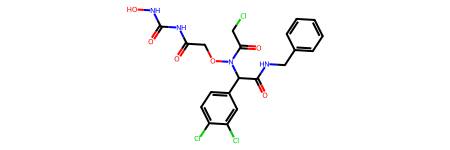

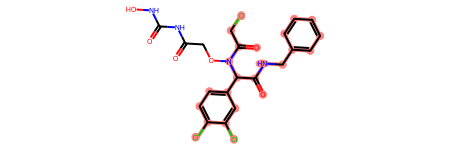

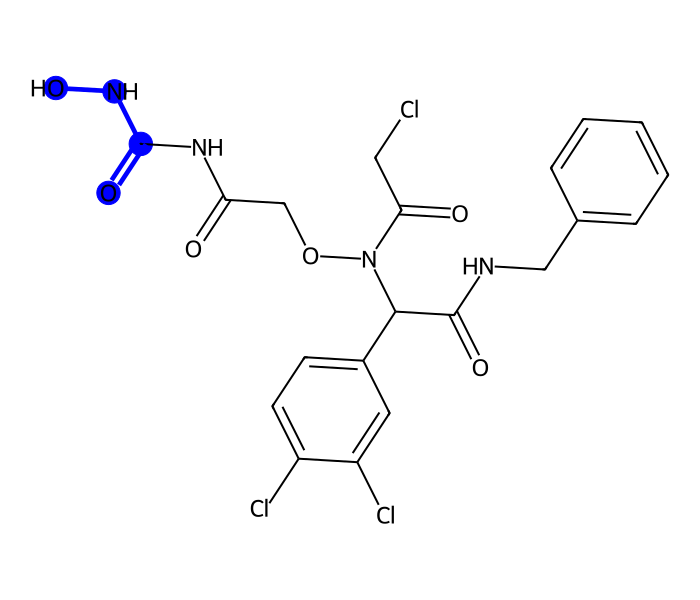

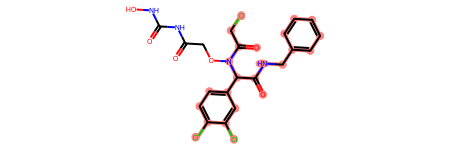

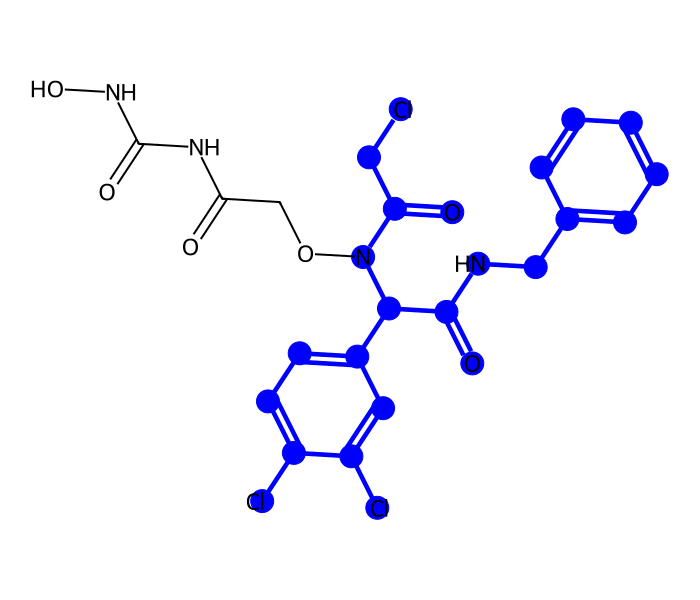

/tmp/ipykernel_9351/3239167328.py:207: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data.substructure_labels = torch.tensor(self.substructure_labels[idx], dtype=torch.long)
Loading datasets:  33%|███▎      | 1/3 [00:07<00:14,  7.34s/it]

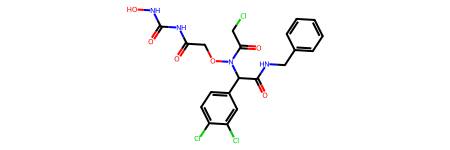

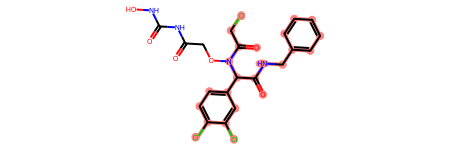

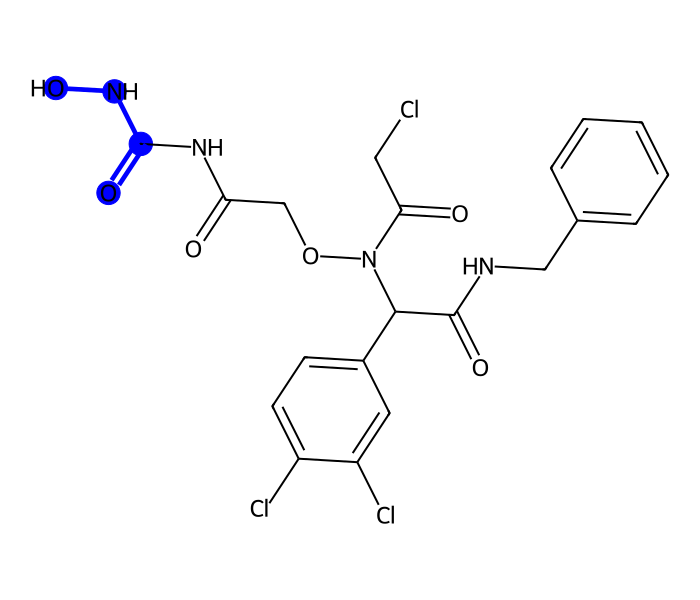

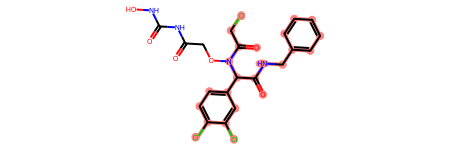

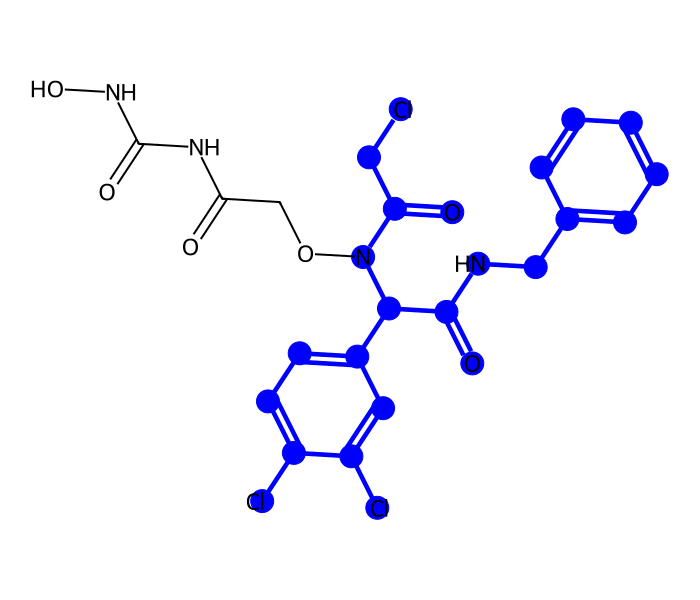

Loading datasets:  67%|██████▋   | 2/3 [00:14<00:07,  7.34s/it]

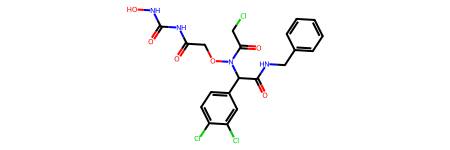

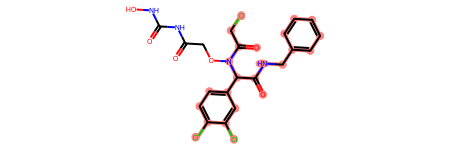

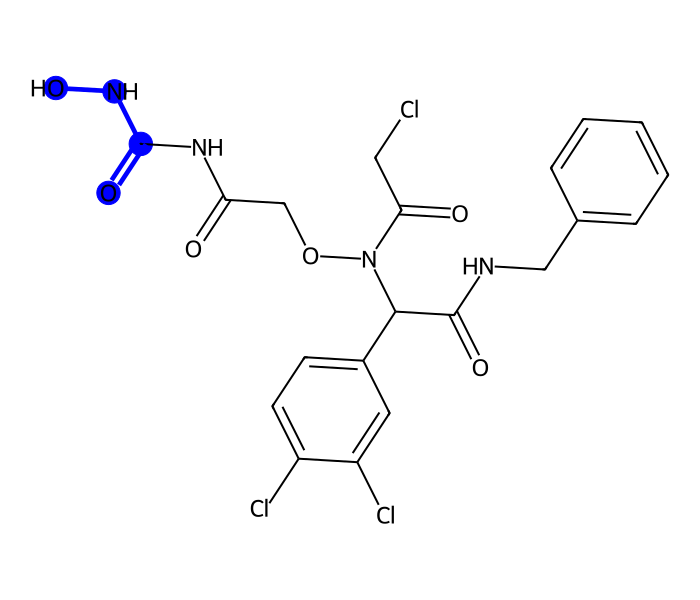

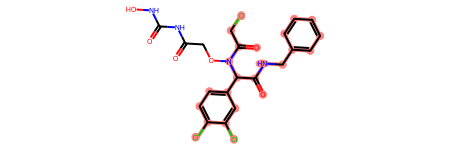

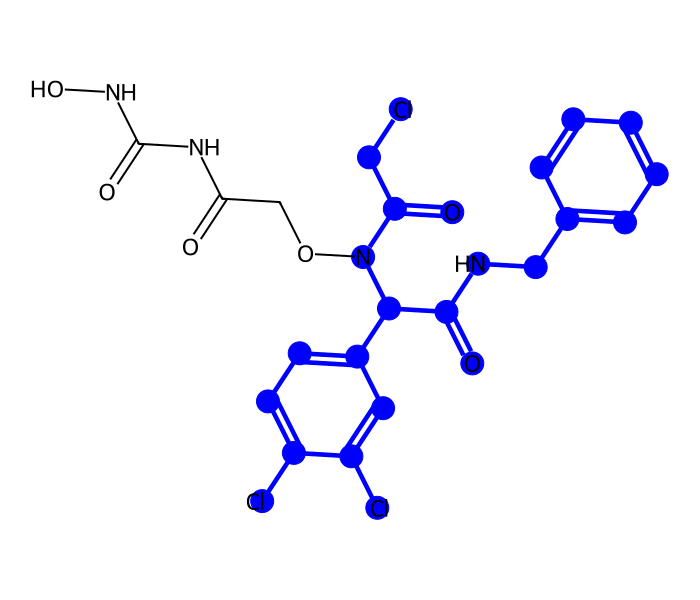

Loading datasets: 100%|██████████| 3/3 [00:21<00:00,  7.32s/it]


In [9]:
dataset_paths_tinytest = {
    "Train": "../../data/augmented/protac_pub_test_protac_228_randBonds_ButinaClusterCutoff_0.3.csv",
    "Validation": "../../data/augmented/protac_pub_test_protac_228_randBonds_ButinaClusterCutoff_0.3.csv",
    "Test PROTAC3": "../../data/augmented/protac_pub_test_protac_228_randBonds_ButinaClusterCutoff_0.3.csv"

}
load_datasets = False
if True:
    if use_crossfolds:
        num_crossfolds = 5
    else:
        num_crossfolds = 1
    ProtacDataset_loader = ProtacLoader(dataset_paths=dataset_paths_tinytest, model_type=model_type, node_descriptors=node_descriptors, graph_descriptors=graph_descriptors, use_crossfolds=use_crossfolds)
    if not load_datasets:
        datasets_dict = ProtacDataset_loader.initialize_datasets(dataframes=ProtacDataset_loader.load_dataframes(),
                                                                num_crossfolds=num_crossfolds, precompute_splits=True)

In [ ]:
if False:
    ProtacDataset_loader = ProtacLoader(dataset_paths=dataset_paths, 
                                        model_type="node_pred", 
                                        node_descriptors=node_descriptors, 
                                        graph_descriptors=graph_descriptors, 
                                        use_crossfolds=use_crossfolds,
                                        )
    datasets_dict = ProtacDataset_loader.initialize_datasets(dataframes=ProtacDataset_loader.load_dataframes(),
                                                                num_crossfolds=1, precompute_splits=True)
else:
    if use_crossfolds:
        num_crossfolds = 5
    else:
        num_crossfolds = 1
    ProtacDataset_loader = ProtacLoader(dataset_paths=dataset_paths, model_type=model_type, node_descriptors=node_descriptors, graph_descriptors=graph_descriptors, use_crossfolds=use_crossfolds)
    if not load_datasets:
        datasets_dict = ProtacDataset_loader.initialize_datasets(dataframes=ProtacDataset_loader.load_dataframes(),
                                                                num_crossfolds=num_crossfolds, precompute_splits=True)

In [ ]:
if save_datasets:
    ProtacDataset_loader.save_datasets_to_file(dataset_path='NEWdatasets_rdkit_betweenness_randbond_bondpred_NewProtacLoader_linkpred.pickle')
if load_datasets:
    datasets_dict = ProtacDataset_loader.load_datasets_from_file(dataset_path='NEWdatasets_rdkit_betweenness_randbond_bondpred_NewProtacLoader_linkpred.pickle')

Do crossfold for 3 testsplits! (SAME train data, different test)

# Optuna (outdated)

In [ ]:
use_optuna = False

In [ ]:
def objective(trial, max_epochs=2, model_type='link_pred', datasets_optuna=[], objective_value='test_accuracies', testset_to_optimize_for = 0):
    #Optuna logic


    #try:
    if True:
        outputs = []
        #for train_CV_set, val_CV_set in zip(datasets_optuna[0], datasets_optuna[1]):
        if True:
            lr = trial.suggest_float("lr", 1e-6, 5e-3, log=True) #0.000058 #trial.suggest_float("lr", 1e-7, 5e-3, log=True)
            batch_size = 1 #trial.suggest_categorical("batch_size", [1, 4, 16, 32, 64])
            if batch_size > 1:
                use_batch_normalization = True
            else:
                use_batch_normalization = False
            criterion_reduction = "sum" 
            num_layers = trial.suggest_int('num_layers', 5, 14)  
            layer_sizes = [128, 512, 1024, 1536]  # Allowed layer sizes
            layer_dims = [trial.suggest_categorical('layer_dims', layer_sizes)]*num_layers # [trial.suggest_categorical(f'layer_dim_{i}', layer_sizes) for i in range(num_layers)]
            dropout_rate = trial.suggest_float("dropout_rate", 0, 0.5) 
            
            #output_layer_type = trial.suggest_categorical('output_layer_type', ['linear', 'gnn'])
            output_layer_type =  'linear_linkpred_symmetric' #trial.suggest_categorical('output_layer_type', ['linear_linkpred', 'linear_linkpred_symmetric', 'linear_linkpred_global', 'linear_linkpred_symmetric_global'])
            #gnn_layer_type = trial.suggest_categorical('gnn_layer_type', ['SAGEConv', 'TransformerConv']) #, 'AttentiveFP'])  GINConv
            #gnn_layer_type = "GraphConv" # trial.suggest_categorical('gnn_layer_type', ['GraphConv', 'GCNConv', 'GATConv', 'SAGEConv', 'TransformerConv']) #, 'AttentiveFP'])  GINConv
            gnn_layer_type = trial.suggest_categorical('gnn_layer_type', ['GATConv', 'TransformerConv']) #, 'AttentiveFP'])  GINConv
            #layer_type_settings = { 'GraphConv': ['setting1', 'setting2'], ...
            #                       }

            use_jumping_knowledge = False
            use_skip_connections = True
            use_graph_normalization = True
            use_edge_information = True
            use_MeanSubtractionNorm = True
            use_new_postprocessing_algorithm = False

            regression_criterion = None# trial.suggest_categorical('regression_criterion', ['nn.L1Loss()', 'None'])
            #if regression_criterion == 'None':
            #    regression_criterion = None
            #elif regression_criterion == 'nn.L1Loss()':
            #    regression_criterion = nn.L1Loss()

            activationfunction = 'lrelu' # trial.suggest_categorical('activationfunction', ['relu', 'lrelu'])
            last_activation_function = None # trial.suggest_categorical('last_activation_function', ['nn.Sigmoid()', 'None'])
            #if last_activation_function == 'None':
            #    last_activation_function = None
            #elif last_activation_function == 'nn.Sigmoid()':
            #    last_activation_function = nn.Sigmoid()
                
        
            
            #use_girvan_newman = trial.suggest_categorical('use_girvan_newman', [True, False])
            #set_use_girvan_newman_encoding_datasets(datasets=datasets, bool=use_girvan_newman)

            #must have precomputed every graph descriptor
            #use_degree = trial.suggest_categorical('use_degree', ['degree', ''])
            #use_closeness = trial.suggest_categorical('use_closeness', ['closeness', ''])
            #use_betweenness = trial.suggest_categorical('use_betweenness', ['betweenness', ''])
            #use_eigenvector = trial.suggest_categorical('use_eigenvector', ['eigenvector', ''])
            #use_local_betweenness_5 = trial.suggest_categorical('use_local_betweenness_5', ['local_betweenness_5', ''])
            #use_local_eigenvectors_x = trial.suggest_categorical('use_local_eigenvectors_x', ['local_eigenvectors_x', ''])
            #selected_optuna_graph_descriptors = [use_degree, use_closeness, use_betweenness, use_eigenvector, use_local_betweenness_5, use_local_eigenvectors_x]
            #while (selected_optuna_graph_descriptors.count('')):
            #    selected_optuna_graph_descriptors.remove('') 
            #set_use_graph_descriptors_datasets(datasets = selected_optuna_graph_descriptors, graph_descriptor_list = selected_optuna_graph_descriptors)


            #Initialize model
            if 'model' in locals():
                del model
            
            num_layers = len(layer_dims)
            node_feature_dim = datasets[2].num_node_features
            if num_layers<=4 and max(layer_dims)<=128:
                device = torch.device("cpu") #"cuda" if torch.cuda.is_available() else "cpu") #"cpu") ## cuda makes the size of the network no longer matter in terms of epoch-time?! (64=1024 dimensions) On cpu it is 7 s vs 1min 30 seconds. GPU: 14 s vs 14 s
            else:
                device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #"cpu") ## cuda makes the size of the network no longer matter in terms of epoch-time?! (64=1024 dimensions) On cpu it is 7 s vs 1min 30 seconds. GPU: 14 s vs 14 s
            num_predicted_classes = 3
            #set_model_type_datasets(datasets=[train_CV_set, val_CV_set], model_type=model_type)
            #model = PROTACSplitter_2(model_type=model_type, node_feature_dim=node_feature_dim, 
            #                                    layer_dims=layer_dims, output_layer_type=output_layer_type,
            #                                   gnn_layer_type=gnn_layer_type, device=device)
            
            init_params = {'model_type': model_type, 
               'node_feature_dim': node_feature_dim, 
               'layer_dims': layer_dims, 
               'gnn_layer_type':gnn_layer_type, 
               'output_layer_type': output_layer_type, 
               'activationfunction': activationfunction, 
               'num_predicted_classes': num_predicted_classes,
               'device': device,
               'dropout_rate': dropout_rate,
               'use_batch_normalization': use_batch_normalization,
               'last_activation_function': last_activation_function,
               'use_edge_information': use_edge_information,
               'use_jumping_knowledge': use_jumping_knowledge,
               'use_skip_connections': use_skip_connections,
               'use_graph_normalization': use_graph_normalization,
               'use_MeanSubtractionNorm': use_MeanSubtractionNorm}
            model = PROTACSplitter_2(init_params=init_params)


            # Model parameters
            
            #criterion_weights = torch.tensor([1.0, 1.0, 1.0])
            optimizer = optim.Adam
            criterion = nn.CrossEntropyLoss(reduction=criterion_reduction) # weight=criterion_weights,  problem with transfering these to the GPU... skip
            num_workers_dataloader = 1

        
            #Early stopping parameters
            num_epochs = 100
            val_early_stopping = True #model looks back 2*n epochs to decide if it shall continue or stop, depending on validation loss. IF median has increased => Stop.
            median_over_n_val_losses = None
            min_over_n_val_losses = 4

            #max_epochs = 5
            stop_if_val_acc_below_x_at_n_list = [ #{'val_frac_criteria': 0.42, 'n_epochs': 1}, # good cutoff for node predictions
                                                {'val_frac_criteria': 0.2, 'n_epochs': 2}, #{'val_frac_criteria': 0.7, 'n_epochs': 2},
                                                {'val_frac_criteria': 0.3, 'n_epochs': 3}, # {'val_frac_criteria': 0.8, 'n_epochs': 3}, 
                                                {'val_frac_criteria': 0.5, 'n_epochs': 3},# {'val_frac_criteria': 0.9, 'n_epochs': 4}, 
                                                {'val_frac_criteria': 0.65, 'n_epochs': 5},#{'val_frac_criteria': 0.65, 'n_epochs': 8},
                                                {'val_frac_criteria': 0.85, 'n_epochs': 10},
                                                {'val_frac_criteria': 0.9, 'n_epochs': 40}] #[x,n]   #if below 60% accuracy at 5 epochs, abort: x% at n epochs

            print_every_n_epochs = 1
            compute_pretrained_values = False

            
            structure_type =  "poi_linker_e3"#"ligand_linker" #"poi_linker_e3" #


            # Train loop
            model.to(device=device)
            output = model.train_model( datasets=datasets_optuna,
                                dataset_names=dataset_names,
                                optimizer=optimizer,
                                criterion=criterion,
                                regression_criterion = regression_criterion,
                                lr=lr, 
                                batch_size=batch_size,
                                epochs=num_epochs, 
                                max_epochs=max_epochs,
                                shuffle=True,
                                val_early_stopping=val_early_stopping,
                                median_over_n_val_losses=median_over_n_val_losses,
                                stop_if_val_acc_below_x_at_n_list=stop_if_val_acc_below_x_at_n_list,
                                print_every_n_epochs=print_every_n_epochs,
                                datasets_to_print=[0, 1, 2], #number of elements is what matters, not which or how many: train->val->testsets
                                compute_pretrained_values=compute_pretrained_values,
                                structure_type=structure_type,
                                e3_database=None,
                                poi_database=None,
                                curriculum_learn_on_ligandLinker_for_x_epochs = 0,
                                use_new_postprocessing_algorithm = use_new_postprocessing_algorithm
        )
        
            # Return a metric to optimize, e.g., negative validation loss or accuracy
            
            if testset_to_optimize_for is not None:
                metric = max(output[objective_value][testset_to_optimize_for])  # Replace 'val_metric' with the actual output metric from your training function
            else:
                metric = max(output[objective_value]) 
            outputs.append(metric)
        
        avg_output = sum(outputs)/len(outputs)
        return avg_output
    #except:
    else:
        return 0.65  #if error, such as out of memory, then poor accuracy.

In [ ]:
existing_study_paths = ['link_pred_study1_.pickle', 
                        'link_pred_study2_.pickle', 
                        'link_pred_study3_.pickle', 
                        'link_pred_study4_batchnorm.pickle', 
                        'link_pred_study5.pickle',
                        'link_pred_study6.pickle',
                        'link_pred_study7_graphdesc.pickle',
                        'link_pred_study8_bondinfo.pickle']
if use_optuna:
    
    n_trials = 100
    study_path = 'link_pred_study9_NEWdataset_optimizeOnTestPROTAC.pickle' # ''
    
    if study_path != '':
        for _ in range(n_trials):
            if not os.path.exists(study_path):
                study = optuna.create_study(direction='maximize') # Use 'minimize' if you are returning a loss
                study.optimize(objective, n_trials=1)
                with open(study_path, 'wb') as file:
                    pickle.dump(study, file)
            else:
                with open(study_path, 'rb') as file:
                    study = pickle.load(file)
                study.optimize(objective, n_trials=1)
                with open(study_path, 'wb') as file:
                    pickle.dump(study, file)
    else:
        study = optuna.create_study(direction='maximize') # Use 'minimize' if you are returning a loss
        study.optimize(objective, n_trials=n_trials)


    print("Number of finished trials: ", len(study.trials))
    print("Best trial:")
    trial = study.best_trial

    print("  Value: ", trial.value)
    print("  Params: ")
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))

In [ ]:
load_pickled_study = False

if use_optuna or load_pickled_study:

    #load study
    if load_pickled_study:
        study_path = 'link_pred_study9_NEWdataset_optimizeOnTestPROTAC.pickle' # ''
        if os.path.exists(study_path):
            with open(study_path, 'rb') as file:
                study = pickle.load(file)


    #get table of best runs
    optuna_study_params = []
    study_dict = {}
    study_dict['Validation accuracy'] = []
    for s in study.get_trials():
        study_dict['Validation accuracy'].append(s.values[0])
        #optuna_study_val_accs.append(s.values)
        for k, v in s.params.items():
            if k not in study_dict:
                study_dict[k] = []
            study_dict[k].append(v)

    all_values_same_length = True #may be false if the number of layers varies
    prev_length = None
    for k, v in study_dict.items():
        if prev_length is None:
            prev_length = len(v)
        elif prev_length != len(v):
            all_values_same_length = False

    if all_values_same_length:
        study_dataframe = pd.DataFrame(study_dict)
        study_dataframe = study_dataframe.sort_values(by=['Validation accuracy'], ascending=False)
        print("Best trials and their parameters:")
        print(study_dataframe.head(50))
        
        
        
    #plot optuna plots
    best_params = study.best_params
    study_parameters = []
    for s in study.get_trials():
        for k, v in s.params.items():
            if k not in study_parameters:
                study_parameters.append(k)
    display(optuna.visualization.plot_parallel_coordinate(study))
    study_parameters_2 = study_parameters.copy()
    study_parameters_2.remove('lr')
    display(optuna.visualization.plot_param_importances(study, params=study_parameters))
    display(optuna.visualization.plot_slice(study, params=study_parameters))
    display(optuna.visualization.plot_contour(study))




    #plot acc vs lr, colored by batch size
    optuna_study_val_accs = []
    optuna_study_param_vals = []
    optuna_study_param = 'lr'
    optuna_study_param_vals_to_color_by = []
    optuna_study_param_to_color_by = 'batch_size'
    plt.figure(figsize=(10, 6))
    for s in study.get_trials():
        optuna_study_val_accs.append(s.values)
        optuna_study_param_vals.append(s.params[optuna_study_param])
        optuna_study_param_vals_to_color_by.append(s.params[optuna_study_param_to_color_by])
        #trial_param = s.params[optuna_study_param]
        #trial_val_acc = s.values
        #trial_color_param_val = s.params[optuna_study_param_to_color_by]


    optuna_study_param_vals_to_color_by_set = sorted(set(optuna_study_param_vals_to_color_by))
    colors = plt.cm.jet(np.linspace(0, 1, len(optuna_study_param_vals_to_color_by_set)))

    labels_in_legend =[]
    for trial_param, trial_val_acc, optuna_study_param_to_color_by in zip(optuna_study_param_vals, optuna_study_val_accs, optuna_study_param_vals_to_color_by):
        color = colors[optuna_study_param_vals_to_color_by_set.index(optuna_study_param_to_color_by)]
        label = f'Batch Size: {optuna_study_param_to_color_by}'
        if label in labels_in_legend:
            label=''
        plt.scatter([trial_param], [trial_val_acc], color=color, label=label)
        if label not in labels_in_legend and label != '':
            labels_in_legend.append(label)

        

    plt.xlabel('Learning Rate (lr)')
    plt.ylabel('Validation Accuracy')
    plt.title('Validation Accuracy vs Learning Rate for Different Batch Sizes')
    plt.xscale('log')  # Since lr values are usually in a log scale
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles,labels, loc='upper left')

    plt.legend(loc='upper left')
    plt.grid(True)
    plt.show()






# Train model

In [ ]:
num_layers = 7
dataset_keys = list(datasets_dict.keys())
if "train_CV" in dataset_keys:
    train_key = "train_CV"
    node_feature_dim = datasets_dict[train_key][0].num_node_features
    model_type = datasets_dict[train_key][0].model_type
elif "Train" in dataset_keys:
    train_key = "Train"
    node_feature_dim = datasets_dict[train_key].num_node_features
    model_type = datasets_dict[train_key].model_type
else:
    raise ValueError("No 'Train' or 'train_CV' dataset in datasets_dict")

output_layer_config = [{
        'type': 'linear_symmetric',  # Indicates symmetric processing but not global
        'in_features': -1,  # Input features to the first output layer
        'intermediate_features': 512,  # Size for the middle layer in the sequence
        'out_features': 3,  # Size for the final classification/prediction layer
        'depth': 3,  # Total number of layers in this sequence
    }]


boundary_layer_config = [{
        'type': 'linear_symmetric',  # Indicates the use of symmetric and global adjustments
        'in_features': -1,  # Input features to the first boundary layer
        'intermediate_features': 512,  # Intermediate layer size (if applicable)
        'out_features': 2,  # Final output size for boundary prediction
        'depth': 3,  # Total number of layers in this sequence
    }]

# Configuration and hyperparameters
layer_dim = 512
init_params = {
    'model_type': model_type,
    'node_feature_dim': node_feature_dim, 
    'device': torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    'num_predicted_classes': 3,
    
    'num_layers': num_layers,
    'layer_dims': [layer_dim for _ in range(num_layers)],
    'final_layer_dim': layer_dim if model_type=="link_pred" else 3,
    'gnn_layer_type': "TransformerConv",
    
    'TransformerConvHeads': 1,
    'TransformerConvBeta': False,
    'TransformerConvDropout': 0,

    'activationfunction': "lrelu",
    'last_activation_function': None,

    'regularization_types': [],
    'dropout_rate': 0.14,
    
    'use_jumping_knowledge': False,
    'use_skip_connections': True,
    'use_graph_normalization': True,
    'use_edge_information': False,
    'use_MeanSubtractionNorm': True,
    'use_batch_normalization': False,

    'output_layer_config': output_layer_config,
    'boundary_layer_config': boundary_layer_config
}    

e3_library = pd.read_csv('../../data/e3_trainval_substructures_without_attachment.csv')["E3 SMILES"].to_list()
poi_library = pd.read_csv('../../data/poi_trainval_substructures_without_attachment.csv')["POI SMILES"].to_list()


# Model training parameters
train_params = {
    'datasets_dict': datasets_dict,
    'optimizer': optim.Adam,
    'lr': 0.000048,
    'batch_size': 1,
    'criterion': nn.CrossEntropyLoss(reduction='sum'),
    'epochs': 100,
    'max_epochs': 1,
    'val_early_stopping': False,
    'median_over_n_val_losses': None,
    'min_over_n_val_losses': 5,
    'stop_if_val_acc_below_x_at_n_list': None,
    'print_every_n_epochs': 1,
    'compute_pretrained_values': False,
    'compute_rand_accuracy': True,
    'e3_library': e3_library,
    'poi_library': poi_library,
    'fp_function': compute_countMorgFP,
    'use_new_postprocessing_algorithm': False
}

# Adjust use_batch_normalization based on batch_size
if train_params['batch_size'] > 1:
    init_params['use_batch_normalization'] = True

# Model factory function
def create_model(init_params):
    model = PROTACSplitter_2(init_params=init_params)
    model.to(init_params['device'])
    return model

# Cross-validation model training
def crossval_model(init_params, train_params, datasets_dict):
    outputs = []
    datasets_dict_temp = datasets_dict.copy()

    for train_CV_set, val_CV_set in tqdm(zip(datasets_dict["train_CV"], datasets_dict["val_CV"]), desc="Crossfolds"):
        model = create_model(init_params)
        datasets_dict_temp["train_CV"] = train_CV_set
        datasets_dict_temp["val_CV"] = val_CV_set
        train_params["datasets_dict"] = datasets_dict_temp
        output = model.train_model(train_params)
        outputs.append(output)
    return outputs, model


# Time tracking for training duration
start_time = datetime.now()
if use_crossfolds:
    outputs, model = crossval_model(init_params, train_params, datasets_dict)
else:
    model = create_model(init_params)
    output = model.train_model(train_params = train_params)
finishing_time = datetime.now()
print(f"Training started at {start_time} and finished at {finishing_time}")
timedelta_to_train_model = finishing_time - start_time
minutes_to_train_model = timedelta_to_train_model.seconds/(60*num_crossfolds)
minutes_per_epoch = minutes_to_train_model/(model.epoch+int(train_params['compute_pretrained_values']))

In [ ]:
#invalid predicted linker for : 

In [ ]:
datasets_dict

for k, v in datasets_dict.items():
    for protac_idx, protac in enumerate(v):

        if len(protac.substructure_labels.unique()) != 3:
            print(f'{k}: {protac_idx}')



Loading datasets:   0%|          | 0/3 [00:00<?, ?it/s]

tensor([1, 1, 1, 0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1])
(3, 4)
tensor([0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 0, 0, 0, 0, 0])


Loading datasets:   0%|          | 0/3 [00:04<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
tensor([1, 1, 1, 0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1])
(3, 4)
tensor([0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 0, 0, 0, 0, 0])

In [85]:
class_nodes =[0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0]
poi_indices = [i for i in range(len(class_nodes)) if class_nodes[i] == 2]


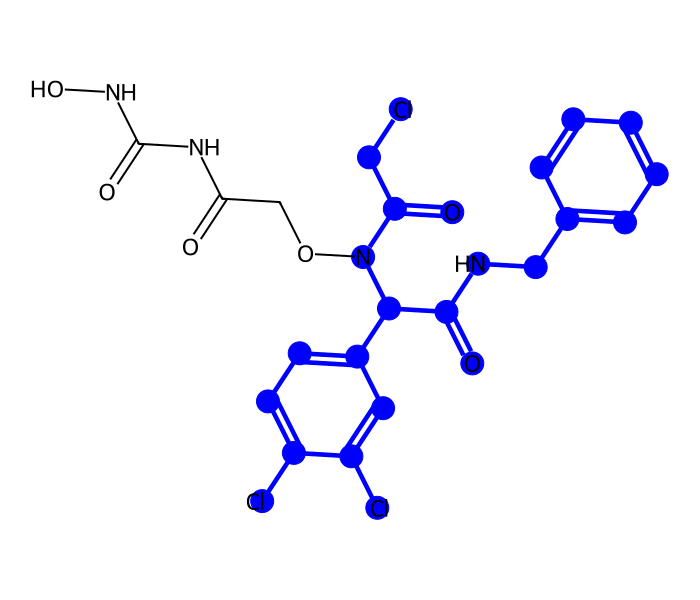

In [86]:
smi = "O=C(CON(C(=O)CCl)C(C(=O)NCc1ccccc1)c1ccc(Cl)c(Cl)c1)NC(=O)NO"
mol = Chem.MolFromSmiles(smi)
draw_molecule_with_highlighted_atoms(mol=mol, atoms_to_highlight=poi_indices)

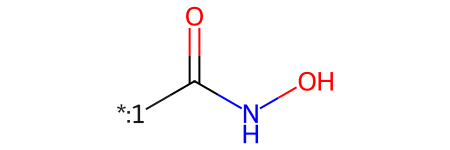

In [64]:
Chem.MolFromSmiles("O=C(NO)[*:1]")

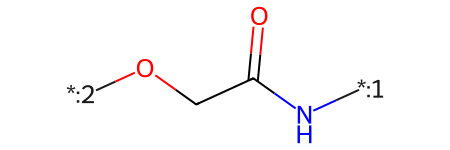

In [65]:
Chem.MolFromSmiles("O=C(CO[*:2])N[*:1]")

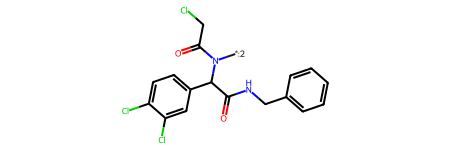

In [66]:
Chem.MolFromSmiles("O=C(NCc1ccccc1)C(c1ccc(Cl)c(Cl)c1)N(C(=O)CCl)[*:2]")

In [ ]:
datasets_dict["Test PROTAC"][120].substructure_labels.unique()

In [ ]:
Chem.MolFromSmiles("O=C(CON(C(=O)CCl)C(C(=O)NCc1ccccc1)c1ccc(Cl)c(Cl)c1)NC(=O)NO")
#                   O=C(CON(C(=O)CCl)C(C(=O)NCc1ccccc1)c1ccc(Cl)c(Cl)c1)NC(=O)NO

"""Found invalid smiles for LINKER SMILES in PROTAC SMILES: O=C(CON(C(=O)CCl)C(C(=O)NCc1ccccc1)c1ccc(Cl)c(Cl)c1)NC(=O)NO
Predicted subtrsuctures:
{'POI SMILES': 'O=C(CO)NC(=O)NO', 'LINKER SMILES': None, 'E3 SMILES': 'O=C(CCl)NC(C(=O)NCC1=CC=CC=C1)C1=CC=C(Cl)C(Cl)=C1'}
{'LINKER SMILES': None, 'E3 SMILES': None, 'POI SMILES': None}"""

#TRUE STRUCTURE GOT NO LINKER??? STILL, HOW CAN THE MODEL PREDICT A STRUCTURE WITHOUT A LINKER???

In [ ]:
output["validity"]

In [ ]:
metrics_template = {'Accuracy': [], 'FP_FN': {}, 'Precision': [], 'Recall': [], "F1": [], "Specificity": [], "MCC": [], 'Jaccard': []}
        
metrics = {
                        "model": {"PROTAC": copy.deepcopy(metrics_template), 
                                   "POI": copy.deepcopy(metrics_template), 
                                   "LINKER": copy.deepcopy(metrics_template), 
                                   "E3": copy.deepcopy(metrics_template), 
                                   "LIGANDS": copy.deepcopy(metrics_template) }, 
                        
                        "model+check_library": {"PROTAC": copy.deepcopy(metrics_template), 
                                                "POI": copy.deepcopy(metrics_template), 
                                                "LINKER": copy.deepcopy(metrics_template), 
                                                "E3": copy.deepcopy(metrics_template), 
                                                "LIGANDS": copy.deepcopy(metrics_template) }
                        }

true_structure_nodes = torch.tensor([1, 1, 0, 0, 0, 0, 0, 0, 0, 0])
pred_structure_nodes = torch.tensor([1, 0, 0, 0, 0, 0, 1, 1, 0, 0])

metrics = model._calc_eval_metrics(true_structure_nodes=true_structure_nodes, pred_structure_nodes=pred_structure_nodes, metrics = metrics, accuracy_origin="model", structure_type="POI")

print(metrics["model"]["POI"]["FP_FN"])
print(metrics["model"]["POI"]["Precision"])
print(metrics["model"]["POI"]["Recall"])
print(metrics["model"]["POI"]["Accuracy"])


In [ ]:
import time
for protac_data in datasets_dict["Test PROTAC"]:
    a, b = model.predict(protac_smiles=protac_data.smiles, precompute_splits = True)

    for k, v in b.items():
        display(Chem.MolFromSmiles(v))
    
    print("\n\n-------------------------------------\n\n")

In [ ]:
model._print_epoch_metrics()

In [ ]:
target_smi = "CNC(=O)c1ccccc1Nc1cc(Nc2cc(C)c(C3CCN(CCOCCOCCOCCCN4CCN(C(=O)N5C(c6ccc(OC)cc6OC(C)C)=NC(c6ccc(Cl)cc6)C5c5ccc(Cl)cc5)CC4=O)CC3)cc2OC(C)C)ncc1C(F)(F)F"
dataset_name="Test E3"
for idx, protac_data in enumerate(datasets_dict[dataset_name]):
    if protac_data.smiles == target_smi:
        print(idx)

In [ ]:
protac_idx = 6
dataset_name="Test E3"
protac_smiles = datasets_dict[dataset_name][protac_idx].smiles


print("Predicted boundary location and type:")
model.vizualize_pred_boundary_location_and_type(protac_smiles=protac_smiles)


e3_database_fps = compute_countMorgFP(train_params['e3_library'])
poi_database_fps = compute_countMorgFP(train_params['poi_library'])
substructures_smi, substructure_smi_with_attachmentpoints = model.predict(protac_smiles=protac_smiles, e3_database_fps=e3_database_fps, poi_database_fps=poi_database_fps)

print("True Warhead:")
display(Chem.MolFromSmiles(datasets_dict[dataset_name].poi_smiles[protac_idx]))
print("Predicted POI SMILES:")
smi = substructure_smi_with_attachmentpoints["POI SMILES"]
display(Chem.MolFromSmiles(smi))

print("Predicted LINKER SMILES:")
smi = substructure_smi_with_attachmentpoints["LINKER SMILES"]
display(Chem.MolFromSmiles(smi))

print("True E3:")
display(Chem.MolFromSmiles(datasets_dict[dataset_name].e3_smiles[protac_idx]))
print("Predicted E3 SMILES:")
smi = substructure_smi_with_attachmentpoints["E3 SMILES"]
display(Chem.MolFromSmiles(smi))



In [ ]:
protac_smiles = datasets_dict["Train"][2].smiles
mol = Chem.MolFromSmiles(protac_smiles)

protac_data = model.get_protac_data(protac_smiles)[0]
protac_data.to(device=model.device)
bonds_to_highlight = protac_data.splittable_bonds
y_out, yb_out = model.forward(batch=protac_data, edges_to_predict=bonds_to_highlight)
bonds_to_highlight = bonds_to_highlight.tolist()

bond_idx_list = []
for bond_atoms in bonds_to_highlight:
    bond = mol.GetBondBetweenAtoms(bond_atoms[0], bond_atoms[1])
    bond_idx = bond.GetIdx()
    bond_idx_list.append(bond_idx)

yb_out_linearnorm = (yb_out[:,0] - min(yb_out[:,0]))/(max(yb_out[:,0]) - min(yb_out[:,0]))
yb_out_norm = F.softmax(yb_out,dim=1)

y_out_norm = F.softmax(y_out,dim=1)

highlight_bondlocation_colors = {bond_id: (v.item(),0,0) for v, bond_id in zip(yb_out_norm[:,0], bond_idx_list)}
highlight_bondtype_colors = {bond_id: (poi_v.item(),0,e3_v.item()) for poi_v, e3_v, bond_id in zip(y_out_norm[:,0], y_out_norm[:,2], bond_idx_list)}
draw_molecule_with_highlighted_bonds(mol, bond_idx_list, highlight_bondlocation_colors)
draw_molecule_with_highlighted_bonds(mol, bond_idx_list, highlight_bondtype_colors)


# Crossvalidation calculations


## Average & standard deviation of accuracy & loss

In [ ]:
def crossfolds_avg_std(outputs):
    # Assuming 'outputs' is the list containing the outputs from each crossfold with the described structure.

    num_crossfolds = len(outputs)
    output_average_acc_loss = {
        'loss': {},
        'accuracy': {}
    }
    output_std_acc_loss = {
        'loss': {},
        'accuracy': {}
    }

    # Initialize the structure for averaging loss
    for dataset_name in outputs[0]['loss'].keys():
        output_average_acc_loss['loss'][dataset_name] = []
        output_std_acc_loss['loss'][dataset_name] = []

    # Initialize the structure for averaging accuracy
    for accuracy_origin in outputs[0]['accuracy'].keys():
        output_average_acc_loss['accuracy'][accuracy_origin] = {}
        output_std_acc_loss['accuracy'][accuracy_origin] = {}
        for dataset_name in outputs[0]['accuracy'][accuracy_origin].keys():
            output_average_acc_loss['accuracy'][accuracy_origin][dataset_name] = {}
            output_std_acc_loss['accuracy'][accuracy_origin][dataset_name] = {}
            for structure_type in outputs[0]['accuracy'][accuracy_origin][dataset_name].keys():
                output_average_acc_loss['accuracy'][accuracy_origin][dataset_name][structure_type] = []
                output_std_acc_loss['accuracy'][accuracy_origin][dataset_name][structure_type] = []

    # Aggregate and average loss
    for dataset_name in output_average_acc_loss['loss'].keys():
        num_epochs = len(outputs[0]['loss'][dataset_name])
        for epoch in range(num_epochs):
            epoch_losses = [output['loss'][dataset_name][epoch] for output in outputs]
            epoch_avg_loss = sum(epoch_losses) / num_crossfolds
            output_average_acc_loss['loss'][dataset_name].append(epoch_avg_loss)

            epoch_std_loss = statistics.stdev(epoch_losses)
            output_std_acc_loss['loss'][dataset_name].append(epoch_std_loss)


    # Aggregate and average accuracy for an epoch across the crossfolds, for each accuracy origin (model or model+library check), dataset, and accuracy type
    for accuracy_origin in output_average_acc_loss['accuracy'].keys():
        for dataset_name in output_average_acc_loss['accuracy'][accuracy_origin].keys():
            for structure_type in outputs[0]['accuracy'][accuracy_origin][dataset_name].keys():
                for epoch in range(num_epochs):
                    epoch_accuracies = [output['accuracy'][accuracy_origin][dataset_name][structure_type][epoch] for output in outputs]
                    epoch_avg_acc = sum(epoch_accuracies) / num_crossfolds
                    output_average_acc_loss['accuracy'][accuracy_origin][dataset_name][structure_type].append(epoch_avg_acc)

                    epoch_std_acc = statistics.stdev(epoch_accuracies)
                    output_std_acc_loss['accuracy'][accuracy_origin][dataset_name][structure_type].append(epoch_std_acc)
                    

    return output_average_acc_loss, output_std_acc_loss

if use_crossfolds:
    output_average_acc_loss, output_std_acc_loss = crossfolds_avg_std(outputs)

In [ ]:
s = 0
for i in range(len(outputs)):
    s += outputs[i]['accuracy']['model']['train_CV']['E3'][0]
s = s/len(outputs)
if s != output_average_acc_loss['accuracy']['model']['train_CV']['E3'][0]:
    raise ValueError("Incorrect aggregation of wrong pred")
else:
    print("all good")

## Average atoms wrong pred

In [ ]:
def compute_average_wrong_pred(outputs):
    # Initialize the aggregate structure for wrong_pred
    average_wrong_pred = {}

    # Iterate over each crossfold
    for crossfold_data in outputs:
        crossfold_wrong_pred = crossfold_data['wrong_pred']
        
        # Navigate through the hierarchy: dataset name -> epoch -> accuracy_origin -> structure_type
        for dataset_name, epochs_data in crossfold_wrong_pred.items():
            if dataset_name not in average_wrong_pred:
                average_wrong_pred[dataset_name] = [{} for _ in range(len(epochs_data))]
            
            for epoch_index, accuracy_origins in enumerate(epochs_data):
                for accuracy_origin, structure_types in accuracy_origins.items():
                    # Ensure the structure exists in the aggregate for this accuracy_origin
                    if accuracy_origin not in average_wrong_pred[dataset_name][epoch_index]:
                        average_wrong_pred[dataset_name][epoch_index][accuracy_origin] = {}
                    
                    for structure_type, wrong_pred_dict in structure_types.items():
                        # Ensure the structure exists for this structure_type
                        if structure_type not in average_wrong_pred[dataset_name][epoch_index][accuracy_origin]:
                            average_wrong_pred[dataset_name][epoch_index][accuracy_origin][structure_type] = {}
                        
                        # Aggregate data: check existence of each key and sum up values
                        for atom_wrong_pred, count in wrong_pred_dict.items():
                            if atom_wrong_pred in average_wrong_pred[dataset_name][epoch_index][accuracy_origin][structure_type]:
                                average_wrong_pred[dataset_name][epoch_index][accuracy_origin][structure_type][atom_wrong_pred] += count
                            else:
                                average_wrong_pred[dataset_name][epoch_index][accuracy_origin][structure_type][atom_wrong_pred] = count

    return average_wrong_pred

average_wrong_pred = compute_average_wrong_pred(outputs=outputs)

In [ ]:
s = 0
for i in range(len(outputs)):
    num_atoms_wrong = 4
    if num_atoms_wrong in outputs[i]['wrong_pred']['train_CV'][0]['model']['PROTAC']:
        s += outputs[i]['wrong_pred']['train_CV'][0]['model']['PROTAC'][num_atoms_wrong]
if s != average_wrong_pred["train_CV"][0]['model']['PROTAC'][num_atoms_wrong]:
    raise ValueError("Incorrect aggregation of wrong pred")
else:
    print("all good")

## Concatenate Jaccard similarities

In [ ]:
def concatenate_jaccard_sim(outputs):
    # Initialize the concatenation structure for union_norm_pred
    jaccard_sim = {}

    # Iterate over each crossfold
    for crossfold_data in outputs:
        crossfold_union_norm_pred = crossfold_data['union_norm_pred']
        
        # Navigate through the hierarchy: dataset name -> epoch -> accuracy_origin -> structure_type
        for dataset_name, epochs_data in crossfold_union_norm_pred.items():
            if dataset_name not in jaccard_sim:
                jaccard_sim[dataset_name] = [{} for _ in range(len(epochs_data))]
            
            for epoch_index, accuracy_origins in enumerate(epochs_data):
                for accuracy_origin, structure_types in accuracy_origins.items():
                    # Ensure the structure exists in the concat structure for this accuracy_origin
                    if accuracy_origin not in jaccard_sim[dataset_name][epoch_index]:
                        jaccard_sim[dataset_name][epoch_index][accuracy_origin] = {}
                    
                    for structure_type, acc_list in structure_types.items():
                        # Ensure the list exists for this structure_type, else initialize
                        if structure_type not in jaccard_sim[dataset_name][epoch_index][accuracy_origin]:
                            jaccard_sim[dataset_name][epoch_index][accuracy_origin][structure_type] = []
                        
                        # Concatenate data: extend the list with data from the current crossfold
                        jaccard_sim[dataset_name][epoch_index][accuracy_origin][structure_type].extend(acc_list)

    return jaccard_sim

jaccard_sim = concatenate_jaccard_sim(outputs=outputs)

In [ ]:
s = []
for i in range(len(outputs)):
    s += outputs[i]['union_norm_pred']['train_CV'][0]['model']['POI']
if s != jaccard_sim['train_CV'][0]['model']['POI']:
    raise ValueError("Incorrect aggregation of union_norm_pred")
else:
    print("all good")

# Evaluate model

In [ ]:
if use_crossfolds:
    val_acc = output_average_acc_loss['accuracy']['model+check_library']['val_CV']['PROTAC']
else:
    val_acc = output['accuracy']['model+check_library']['Validation']['PROTAC']
idx_max_val_acc = val_acc.index(max(val_acc))


## Number atoms wrong

In [ ]:
if use_crossfolds:
    num_atoms_wrong_dict = average_wrong_pred
else:
    num_atoms_wrong_dict = output["wrong_pred"]


for dataset_name, wrong_preds in num_atoms_wrong_dict.items():
    epoch = idx_max_val_acc #choose epoch at max validation

    wrong_pred_tmp = wrong_preds[epoch]
    for accuracy_origin in wrong_pred_tmp.keys():
        
        for structure_type in wrong_pred_tmp[accuracy_origin].keys():
            num_atoms_wrong = list(wrong_pred_tmp[accuracy_origin][structure_type].keys())
            num_atoms_wrong_occurance = list(wrong_pred_tmp[accuracy_origin][structure_type].values())
            total_atoms_wrong = sum([num*count for num, count in zip(num_atoms_wrong, num_atoms_wrong_occurance)])
            num_predicted_structures = sum([n for n in num_atoms_wrong_occurance])
            average_num_atoms_wrong = total_atoms_wrong / num_predicted_structures
            all_occurances = []
            for atoms_wrong, occurance in wrong_pred_tmp[accuracy_origin][structure_type].items():
                all_occurances.extend([atoms_wrong]*occurance)
            
            all_occurances.sort()

            median_atoms_wrong = median(all_occurances)
            if sum(all_occurances) != total_atoms_wrong:
                pass
            fig, ax1 = plt.subplots()
            ax1.bar(num_atoms_wrong, num_atoms_wrong_occurance, width=1)
            ax1.set_title(label=f"Atoms wrong for {structure_type} in dataset {dataset_name} with {accuracy_origin}\nAvg: {round(average_num_atoms_wrong,1)}, Median: {median_atoms_wrong}")

            ax1.set_xlabel('# Atoms wrong', color="black")
            ax1.set_ylabel('Occurance', color="black", rotation='horizontal')
            ax1.yaxis.set_label_coords(-.18, 0.5)


            fig.show()
            


## Jaccard Similarity

In [ ]:
if use_crossfolds:
    union_norm_pred_dict = jaccard_sim
else:
    union_norm_pred_dict = output["union_norm_pred"]


for dataset_name, union_norm_pred_for_dataset in union_norm_pred_dict.items():
    epoch = idx_max_val_acc #choose epoch at max validation

    union_norm_pred_at_max_val = union_norm_pred_for_dataset[epoch]
    for accuracy_origin in union_norm_pred_at_max_val.keys():
        for structure_type in union_norm_pred_at_max_val[accuracy_origin].keys():
            union_norm_pred = union_norm_pred_at_max_val[accuracy_origin][structure_type]

            median_union_norm_pred = median(union_norm_pred)
            avg_union_norm_pred = sum(union_norm_pred)/len(union_norm_pred)

            fig, ax1 = plt.subplots()
            binwidth = 0.01
            bins = list(np.arange(0,1+binwidth,binwidth))
            ax1.hist(union_norm_pred, range=(0,1), bins=bins)
            ax1.set_title(label=f"{structure_type} in {dataset_name} with {accuracy_origin} : Fraction correct over union(TRUE, PRED) \nAvg: {round(avg_union_norm_pred,3)}, Median: {round(median_union_norm_pred,3)}")
            #ax1.set_xlabel('# Atoms wrong', color="black")
            #ax1.set_ylabel('Occurance', color="black", rotation='horizontal')
            ax1.yaxis.set_label_coords(-.18, 0.5)


            fig.show()
        
    
        

## Unceartainty

In [ ]:
output['boundary_bond_probs']['Train'][0][0]

In [ ]:
confidence = {}
for dataset_name in output['boundary_bond_probs'].keys():
    confidence[dataset_name] = {'lowest_confidence': [], 
                                'confidence_poi_boundary': [],
                                'confidence_e3_boundary': [],
                                'poi_prob_for_poi_boundary': [],
                                'e3_prob_for_poi_boundary': [],
                                'poi_prob_for_e3_boundary': [],
                                'e3_prob_for_e3_boundary': []
                                }
    for protac_boundaries in output['boundary_bond_probs'][dataset_name][epoch]:

        boundary_probs_poi, boundary_probs_e3 = list(protac_boundaries.values())


        confidence_poi_boundary = boundary_probs_poi[0] / (boundary_probs_poi[0]+boundary_probs_poi[2])
        confidence_e3_boundary = boundary_probs_e3[2] / (boundary_probs_e3[0]+boundary_probs_e3[2])
        confidence_lowest_boundary = min([confidence_poi_boundary, confidence_e3_boundary])
        confidence[dataset_name]['poi_prob_for_poi_boundary'].append(boundary_probs_poi[0])
        confidence[dataset_name]['e3_prob_for_poi_boundary'].append(boundary_probs_poi[2])
        confidence[dataset_name]['poi_prob_for_e3_boundary'].append(boundary_probs_e3[0])
        confidence[dataset_name]['e3_prob_for_e3_boundary'].append(boundary_probs_e3[2])
        confidence[dataset_name]['confidence_poi_boundary'].append(confidence_poi_boundary)
        confidence[dataset_name]['confidence_e3_boundary'].append(confidence_e3_boundary)
        confidence[dataset_name]['lowest_confidence'].append(confidence_lowest_boundary)

        
    #

In [ ]:
for dataset_name in dataset_names:
    print(dataset_name)
    print(f'lowest_confidence {round(avg(confidence[dataset_name]["lowest_confidence"]),3) }')
    poi_prob_for_poi_boundary = round(avg(confidence[dataset_name]["poi_prob_for_poi_boundary"]),3)
    e3_prob_for_poi_boundary = round(avg(confidence[dataset_name]["e3_prob_for_poi_boundary"]),3)
    print(f'POI B. : ({poi_prob_for_poi_boundary}, {e3_prob_for_poi_boundary})')
    poi_prob_for_e3_boundary = round(avg(confidence[dataset_name]["poi_prob_for_e3_boundary"]),3)
    e3_prob_for_e3_boundary = round(avg(confidence[dataset_name]["e3_prob_for_e3_boundary"]),3)
    print(f'E3 B. : ({poi_prob_for_e3_boundary}, {e3_prob_for_e3_boundary})')
    print(f'E3 boundary confidence {round(avg(confidence[dataset_name]["confidence_e3_boundary"]),3) }')
    print(f'POI boundary confidence {round(avg(confidence[dataset_name]["confidence_poi_boundary"]),3) }')
    print('\n')

## Display evaluation metrics - WIP

In [ ]:
#Values of best and crossvalidation

In [ ]:



#aggregation function = avg

#table: Columns are structure_type + other metric
#       Rows: datasets

#tables: accuracy_origin


#barplot: a group of bars = structure_type(substructure), within a bar = other metrics
# 2 bar plots: accuracy_origin



In [ ]:
# Assuming output, dataset_name, epoch, accuracy_origin, structure_type are defined
# For illustration, avg and median functions need to be defined or imported as well

epoch=0
dataset_name = "Test POILinker"
accuracy_origin = "model+check_library"

# Calculate the number of metrics to determine the grid size
num_substructures = len(output["metrics"][dataset_name][epoch][accuracy_origin])
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1', 'Specificity', 'MCC', 'Jaccard']
num_metrics = len(metrics_list)
# Calculate grid size (for simplicity, creating a grid of 1 row)
nrows = num_substructures
ncols = num_metrics

# Create subplot grid
fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*num_substructures), sharey=True, sharex=True) # Adjust figsize as needed
if ncols == 1:  # If there's only one subplot, axs may not be an array
    axs = [axs]

binwidth = 0.01
bins = list(np.arange(0, 1 + binwidth, binwidth))

# Iterate over each metric and plot
for axs_structure, (structure_type, metric_dict) in zip(axs, output["metrics"][dataset_name][epoch][accuracy_origin].items()):
    ax_idx = 0
    for metric_type, metric_values in metric_dict.items():
        if metric_type in metrics_list:
            ax = axs_structure[ax_idx]
            ax_idx += 1
            ax.hist(metric_values, range=(0,1), bins=bins)
            ax.set_title(f"{metric_type} for {structure_type} in {dataset_name} from {accuracy_origin}.\nAvg: {round(np.mean(metric_values),2)}, Median: {round(np.median(metric_values),2)}")

plt.tight_layout()  
plt.show

In [ ]:
# Function to calculate average


# Number of epochs to consider for the average calculation
last_epochs = min([5, len(output['train_accuracy']) - 1])

# Extract accuracies
train_acc = output['train_accuracy']
val_acc = output['val_accuracy']
test_protac_acc = output['test_accuracies'][0]
test_poi_acc = output['test_accuracies'][1]
test_linker_acc = output['test_accuracies'][2]
test_e3_acc = output['test_accuracies'][3] 
rand_labels_acc = output['rand_prediction_accuracy'] #[1/3 for _ in output['train_accuracy']] #
accuracies = [train_acc, val_acc, test_protac_acc, test_poi_acc, test_linker_acc, test_e3_acc, rand_labels_acc]

train_acc_check_library = output['train_accuracy_check_library']
val_acc_check_library = output['val_accuracy_check_library']
test_protac_acc_check_library = output['test_accuracies_check_library'][0]
test_poi_acc_check_library = output['test_accuracies_check_library'][1]
test_linker_acc_check_library = output['test_accuracies_check_library'][2]
test_e3_acc_check_library = output['test_accuracies_check_library'][3]
rand_labels_acc_check_library = output['rand_prediction_accuracy_check_library']
accuracies_check_library = [train_acc_check_library, val_acc_check_library, test_protac_acc_check_library, test_poi_acc_check_library, test_linker_acc_check_library, test_e3_acc_check_library, rand_labels_acc_check_library]

if not get_average_output:
    train_acc_postprocessed = output['train_accuracy_postprocessed']
    val_acc_postprocessed = output['val_accuracy_postprocessed']
    test_protac_acc_postprocessed = output['test_accuracies_postprocessed'][0]
    test_poi_acc_postprocessed = output['test_accuracies_postprocessed'][1]
    test_linker_acc_postprocessed = output['test_accuracies_postprocessed'][2]
    test_e3_acc_postprocessed = output['test_accuracies_postprocessed'][3]
    rand_labels_acc_postprocessed = [0 for _ in train_acc] #not really applicable
    accuracies_postprocessed = [train_acc_postprocessed, val_acc_postprocessed, test_protac_acc_postprocessed, test_poi_acc_postprocessed, test_linker_acc_postprocessed, test_e3_acc_postprocessed, rand_labels_acc_postprocessed]


# Calculate average accuracies over the last N epochs
avg_last_accuracy_list = [round(100 * avg(acc[-last_epochs:]), 1) for acc in accuracies]
#avg_last_accuracy_postprocessed_list = [round(100 * avg(acc[-last_epochs:]), 1) for acc in accuracies_postprocessed]

# Data for displaying in DataFrame
data = {'Avg. Last Accuracy (%)': avg_last_accuracy_list} #, 'Postprocessed (%)': avg_last_accuracy_postprocessed_list}
avg_last_accuracy_df = pd.DataFrame(data, index=dataset_names+["Random"])
print(avg_last_accuracy_df)






# Find the epoch with the highest validation accuracy
idx_max_val_acc = val_acc.index(max(val_acc))

# Accuracies at the epoch with the highest validation accuracy
accuracy_at_max_val = [round(100 * acc[idx_max_val_acc], 1) for acc in accuracies]
accuracy_check_library_at_max_val = [round(100 * acc[idx_max_val_acc], 1) for acc in accuracies_check_library]
#accuracy_postprocessed_at_max_val = [round(100 * acc[idx_max_val_acc], 1) for acc in accuracies_postprocessed]

# Data for displaying in DataFrame
data_at_max_val = {'Accuracy at Max Val (%)': accuracy_at_max_val, 'Check library (%)': accuracy_check_library_at_max_val} #, 'Postprocessed (%)': accuracy_postprocessed_at_max_val}
accuracy_at_max_val_df = pd.DataFrame(data_at_max_val, index=dataset_names+["Random"])
print(accuracy_at_max_val_df)

## Plot accuracies

In [ ]:
output_std_acc_loss.keys()

### Plot each dataset

In [ ]:


if use_crossfolds:
    acc_to_plot = output_average_acc_loss
    std_to_plot = output_std_acc_loss
else:
    acc_to_plot = output
keys = list(acc_to_plot['loss'].keys())
train_dataset_name = keys[0]
val_dataset_name = keys[1]

structure_type_to_color = {"PROTAC": 'green', 'POI': 'red', 'LINKER': 'gray', 'E3': 'blue', 'LIGANDS': 'magenta', 'LIGANDS+LINKER': 'purple'}

for accuracy_origin in acc_to_plot['accuracy'].keys():
    for dataset_idx, dataset_name in enumerate(acc_to_plot['accuracy'][accuracy_origin].keys()):

        #Make a plot for all accuracies
        fig, ax1 = plt.subplots()
        ax1.set_xlabel('Epochs', color="black")
        ax1.set_ylabel('Node accuracy', color="black", rotation='horizontal')

        ax1.yaxis.set_label_coords(-.18, 0.5)

        #Fix x-axis and get adaptive tick step size
        x = list(range(1-int(train_params["compute_pretrained_values"]),len(acc_to_plot['loss'][train_dataset_name])+1-int(train_params["compute_pretrained_values"])))
        ax1.ticklabel_format(style='plain', axis='x', useOffset=False)
        allowed_tick_sizes = [1, 2, 5, 10, 25, 50, 100]
        desired_num_tick_steps = 10
        deviation_num_tick_steps = [abs(len(x)//tick_size-desired_num_tick_steps) for tick_size in allowed_tick_sizes]
        chosen_tick_step_size = allowed_tick_sizes[deviation_num_tick_steps.index(min(deviation_num_tick_steps))]
        fig.gca().xaxis.set_major_locator(mticker.MultipleLocator(chosen_tick_step_size))

        accuracy_plots_list = []
        loss_plot_list = []
        for structure_type, acc in acc_to_plot['accuracy'][accuracy_origin][dataset_name].items():
            accuracy_plots_list.append(ax1.plot(x, acc, color=structure_type_to_color[structure_type], label=f'{accuracy_origin}_{structure_type}'))

        if use_crossfolds:
            x_arr = np.array(x)
            for (structure_type, acc), (std_type, std) in zip(acc_to_plot['accuracy'][accuracy_origin][dataset_name].items(), std_to_plot['accuracy'][accuracy_origin][dataset_name].items()):
                acc_arr = np.array(acc)
                std_arr = np.array(std)
                ax1.fill_between(x_arr, acc_arr-std_arr, acc_arr+std_arr, color=structure_type_to_color[structure_type], alpha=0.3)
          

        ax1.tick_params(axis='y', labelcolor="black")
        ax1.set_ylim(bottom=0, top=1)
        ax1.set_xlim(left=min(x), right=max(x))
        #ax1.legend(loc='lower left')
        ax1.set_title(label=f"Node accuracy of {accuracy_origin} for {dataset_name} dataset\ndescriptors: {[node_descriptors] + model.graph_descriptor_list}")

        ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

        if dataset_idx<2:
            if dataset_name == "train_CV":
                loss_legend_txt = "Train"
            elif dataset_name == "val_CV":
                loss_legend_txt = "Validation"
            else:
                loss_legend_txt = dataset_name

            loss_plot_list.append(ax2.plot(x, acc_to_plot['loss'][dataset_name], color="black", linestyle='dotted', label=loss_legend_txt))

        if len(loss_plot_list) > 0:
            #lns = ax2.plot(x, train_loss, color="black", linestyle='dotted', label='Loss')
            ax2.set_yscale(value="log")
            ax2.set_ylabel('Loss', color="black", rotation='horizontal')  # we already handled the x-label with ax1
            ax2.yaxis.set_label_coords(1.12, 0.5)
            ax2.tick_params(axis='y')

        ax3 = ax1.twinx()
        ax3.set_yticks([])
        ax4_dummy = ax1.twinx()
        ax4_dummy.set_yticks([])


        legend_positions = [0.77, 0.45]
        available_axies = [ax1, ax2, ax3, ax4_dummy]
        legend_titles = ['Accuracy', 'Loss']
        plot_list = [l for l in [accuracy_plots_list, loss_plot_list] if len(l)>0]
        if len(plot_list) == 1:
            del available_axies[1]


        for chosen_plot_list, legend_pos, chosen_ax, leg_title in zip(plot_list, legend_positions, available_axies, legend_titles):
            lables = []
            for idx, plot in enumerate(chosen_plot_list):
                label = plot[0].get_label()
                lables.append(label)
                if idx == 0:
                    plots = plot
                else:
                    plots = plots+plot
            #lables = [plot.get_label() for plot in plots]
            leg = chosen_ax.legend(plots, lables, loc='center left', bbox_to_anchor=(1.35, legend_pos), frameon=True, title=leg_title)
            leg.get_frame().set_linewidth(1.0)
            leg.get_frame().set_edgecolor('k')
            #ax1.add_artist(leg)
            #chosen_ax.legend(frameon=True)



        #fig.tight_layout()  # otherwise the right y-label is slightly clipped
        fig.show()


### Plot accuracy for each structure

In [ ]:
dataset_to_color = {"Train": 'black', "train_CV": 'black', "Validation": 'green', 'val_CV': 'green', "Test PROTAC": 'purple', "Test POI": 'red', "Test Linker": 'gray', "Test E3": 'blue', 'Dummy': 'orange'}

if use_crossfolds:
    acc_to_plot = output_average_acc_loss
    std_to_plot = output_std_acc_loss

else:
    acc_to_plot = output

#subplots, (sax1, sax2, sax3, sax4, sax5, sax6) = plt.subplots(3, 2, sharex=True, sharey=True)


if True:
    keys = list(acc_to_plot['loss'].keys())
    train_dataset_name = keys[0]
    val_dataset_name = keys[1]
    for i, structure_type in enumerate(acc_to_plot['accuracy']['model'][train_dataset_name].keys()):
        #Make a plot for all accuracies
        fig, ax1 = plt.subplots()
        ax1.set_xlabel('Epochs', color="black")
        ax1.set_ylabel('Node accuracy', color="black", rotation='horizontal')

        ax1.yaxis.set_label_coords(-.18, 0.5)


        #Fix x-axis and get adaptive tick step size
        
        x = list(range(1-int(train_params["compute_pretrained_values"]),len(acc_to_plot['loss'][train_dataset_name])+1-int(train_params["compute_pretrained_values"])))
        ax1.ticklabel_format(style='plain', axis='x', useOffset=False)
        allowed_tick_sizes = [1, 2, 5, 10, 25, 50, 100]
        desired_num_tick_steps = 10
        deviation_num_tick_steps = [abs(len(x)//tick_size-desired_num_tick_steps) for tick_size in allowed_tick_sizes]
        chosen_tick_step_size = allowed_tick_sizes[deviation_num_tick_steps.index(min(deviation_num_tick_steps))]
        fig.gca().xaxis.set_major_locator(mticker.MultipleLocator(chosen_tick_step_size))


        ax1.tick_params(axis='y', labelcolor="black")
        ax1.set_ylim(bottom=0, top=1)
        ax1.set_xlim(left=min(x), right=max(x))
            #ax1.legend(loc='lower left')
        ax1.set_title(label=f"Node accuracy of {structure_type}\ndescriptors: {[node_descriptors] + model.graph_descriptor_list}")


        accuracy_plots_list = []
        accuracy_plots_check_library_list = []

        for dataset_name in acc_to_plot['accuracy']['model'].keys():
            if dataset_name in ["Test POILinker", "Test POIE3", "Test E3Linker"]:
                #Dont plot these. It will be too much
                continue
            
            acc_tmp = acc_to_plot['accuracy']['model'][dataset_name][structure_type]
            accuracy_plots_list.append(ax1.plot(x, acc_tmp, color=dataset_to_color[dataset_name], label=f'{dataset_name}'))
            acc_check_library_tmp = acc_to_plot['accuracy']['model+check_library'][dataset_name][structure_type]
            accuracy_plots_check_library_list.append(ax1.plot(x, acc_check_library_tmp, color=dataset_to_color[dataset_name], label=f'{dataset_name}', linestyle='dashed'))

            if use_crossfolds:
                std_tmp = std_to_plot['accuracy']['model'][dataset_name][structure_type]
                std_check_library_tmp = std_to_plot['accuracy']['model+check_library'][dataset_name][structure_type]

                x_arr = np.array(x)
                acc_tmp_np = np.array(acc_tmp)
                std_tmp_np = np.array(std_tmp)
                ax1.fill_between(x_arr, acc_tmp_np-std_tmp_np, acc_tmp_np+std_tmp_np, color=dataset_to_color[dataset_name], alpha=0.3)

                acc_check_library_tmp_np = np.array(acc_check_library_tmp)
                std_check_library_tmp_np = np.array(std_check_library_tmp)
                ax1.fill_between(x_arr, acc_check_library_tmp_np-std_check_library_tmp_np, acc_check_library_tmp_np+std_check_library_tmp_np, color=dataset_to_color[dataset_name], alpha=0.3)

        loss_plot_list = []
        ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
        ax2.set_yscale(value="log")
        ax2.set_ylabel('Loss', color="black", rotation='horizontal')  # we already handled the x-label with ax1
        ax2.yaxis.set_label_coords(1.12, 0.5)
        ax2.tick_params(axis='y')
        loss_plot_list.append(ax2.plot(x, acc_to_plot['loss'][train_dataset_name], color="black", linestyle='dotted', label='Train')) #marker='--'
        loss_plot_list.append(ax2.plot(x, acc_to_plot['loss'][val_dataset_name], color="green", linestyle='dotted', label='Validation')) #marker='--'

            

        ax3 = ax1.twinx()
        ax3.set_yticks([])
        ax4_dummy = ax1.twinx()
        ax4_dummy.set_yticks([])


        legend_positions = [0.85, 0.35, -0.02]
        available_axies = [ax1, ax2, ax3, ax4_dummy]
        legend_titles = ['Model accuracy', 'Model+Check Library accuracy', 'Loss']
        plot_list = [accuracy_plots_list, accuracy_plots_check_library_list, loss_plot_list]
        plot_list = [l for l in plot_list if len(l)>0]
        if len(plot_list) == 1:
            del available_axies[1]

        for chosen_plot_list, legend_pos, chosen_ax, leg_title in zip(plot_list, legend_positions, available_axies, legend_titles):
            lables = []
            for idx, plot in enumerate(chosen_plot_list):
                label = plot[0].get_label()
                lables.append(label)
                if idx == 0:
                    plots = plot
                else:
                    plots = plots+plot
            #lables = [plot.get_label() for plot in plots]
            leg = chosen_ax.legend(plots, lables, loc='center left', bbox_to_anchor=(1.35, legend_pos), frameon=True, title=leg_title)
            leg.get_frame().set_linewidth(1.0)
            leg.get_frame().set_edgecolor('k')
            #ax1.add_artist(leg)
            #chosen_ax.legend(frameon=True)

            figs = {structure_type: fig}

            fig.show()




    


## Save fig and data to csv (outdated)

In [ ]:
#train_nodes = 0
#for p in datasets[0][cf_id]:
#    train_nodes += len(p.substructure_labels)
#train_nodes

In [ ]:
import csv
from datetime import datetime

comment = "5xCrossFold_NewDatasets_GraphNorm_MeanSubtractionNorm_withLibraryCheck(see_fig)_Bond&ClassLoss_NodeAccuracy_RDKitNodeFeatures_symmetric-out-linear_randbonds" #f"Crossfold_{cv_id}"

current_now = start_time.strftime("%Y/%m/%d %H:%M:%S")                         
train_acc_at_max_val = output['train_accuracy'][idx_max_val_acc]
val_acc_at_max_val = output['val_accuracy'][idx_max_val_acc]
test_protac_acc_at_max_val = output['test_accuracies'][0][idx_max_val_acc]
test_poi_acc_at_max_val = output['test_accuracies'][1][idx_max_val_acc]
test_linker_acc_at_max_val = output['test_accuracies'][2][idx_max_val_acc]
test_e3_acc_at_max_val = output['test_accuracies'][3][idx_max_val_acc]
random_pred_acc_at_max_val = output['rand_prediction_accuracy'][idx_max_val_acc]      
val_loss_at_max_val = output['avg_val_loss'][idx_max_val_acc]
train_loss_at_max_val = output['avg_train_loss'][idx_max_val_acc]
num_epochs_total = len(output['avg_train_loss']) - int(compute_pretrained_values)
num_epochs_at_max_val = idx_max_val_acc + 1 - int(compute_pretrained_values)
timedelta_to_train_model = finishing_time - start_time
minutes_to_train_model = timedelta_to_train_model.seconds/60                            
minutes_to_train_model_to_max_val = minutes_to_train_model * num_epochs_at_max_val/num_epochs_total
minutes_per_epoch = minutes_to_train_model_to_max_val/num_epochs_at_max_val
num_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)

data_header = ["date",	"comment",	"model_type",      "graph_descriptors",	"val_acc",	"train_acc",	
               "test_protac_acc",	"test_poi_acc",	"test_linker_acc",	"test_e3_acc",	"random_pred_acc",	
               "val_loss",	"train_loss",	"epochs",	"training_time (min)",	"min/epoch",	
               "num_of_parameters",	"num_train_protacs",    "num_train_nodes",
               "gnn_layer_type",	"output_layer_type",	"num_layers",	"layer_dims",	
               "learning_rate",	"batch",	"criterion_reduction",	"activationfunction", "last_activation_function",
               "dropout", "structure_type"]

data = [current_now, comment, model_type, model.graph_descriptor_list, val_acc_at_max_val, train_acc_at_max_val, 
        test_protac_acc_at_max_val, test_poi_acc_at_max_val, test_linker_acc_at_max_val, test_e3_acc_at_max_val, random_pred_acc_at_max_val,
        val_loss_at_max_val, train_loss_at_max_val, num_epochs_at_max_val, minutes_to_train_model_to_max_val, minutes_per_epoch,
        num_parameters, len(datasets[0]), model.total_train_nodes,  #incase you are doing crossfolds, use: train_nodes
        model.gnn_layer_type, model.output_layer_type, num_layers, layer_dims,
        lr, batch_size, criterion_reduction, activationfunction, last_activation_function,
        dropout_rate, structure_type]

name_csv_results = "protac_splitter_results_v2.csv"

if not os.path.exists(name_csv_results):
    with open(name_csv_results, 'w') as file_writer:
        writer = csv.writer(file_writer)
        writer.writerow(data_header)

df_results = pd.read_csv(name_csv_results)
row_dict = {col: val for col, val in zip(data_header, data)}
df_results.loc[len(df_results.index)] = row_dict
df_results.to_csv(name_csv_results, index=False)

In [ ]:
#save figure - match to date in csv
fig_path = f'fig/{start_time.strftime("%Y%m%d_%H%M%S")}.png'
if not os.path.exists(fig_path):
    fig.savefig(fig_path) 
else: #for when doing crossfolds, as they share the same start_time...
    png_idx=1
    fig_path = f'fig/{start_time.strftime("%Y%m%d_%H%M%S")}_{png_idx}.png'
    while os.path.exists(fig_path): # when the file does exist, increment by 1 and check again until it doesnt exist
        png_idx += 1
        fig_path = f'fig/{start_time.strftime("%Y%m%d_%H%M%S")}_{png_idx}.png'
    fig.savefig(fig_path)



In [ ]:
name_csv_results = "protac_splitter_results_v2.csv"
df_results = pd.read_csv(name_csv_results)

print(df_results)

In [ ]:
if False: #delete last row in saved csv
    df_results = pd.read_csv(name_csv_results)
    df_results.drop(df_results.tail(1).index,inplace=True)
    df_results.to_csv(name_csv_results, index=False)

## Plot confusion matrices of substructure labels (outdated)

In [ ]:
def plot_confusion_matrix_substructure_labels(model, datasets, dataset_names, use_library=True,):

    flipped_predictions_datasets = {}

    confusion_matrices = []
    e3_database_fps = compute_countMorgFP(e3_library)
    poi_database_fps = compute_countMorgFP(poi_library)

    for dataset, dataset_name in zip(datasets, dataset_names):
        flipped_predictions = {'PROTACs': {}, 'POI': {}, 'E3': {}}

        confusion_matrix = [[0, 0, 0] for _ in range(3)]

        loader = DataLoader(dataset=dataset, batch_size=1, shuffle=False)

        count_nodes = 0
        count_correct_ligand_and_linker_nodes = 0
        
        for protac_idx, batch in enumerate(loader): #tqdm(dataset):
            batch = batch.to(model.device)

            count_correct_ligand_and_linker_nodes_tmp =0
            count_correct_nodes_tmp =0
            
            
            if model.model_type == "link_pred":
                edges_to_predict = batch["splittable_bonds"]
                raw_prediction, yb = model.forward(batch, edges_to_predict=edges_to_predict)  # Forward pass
            else:
                raw_prediction, yb = model.forward(batch)

            predicted_boundary_bonds = torch.topk(yb[:,0], k=2, dim=0).indices.tolist()
                #delta_poi_boundary_score = output[predicted_boundary_bonds[0], 0] - output[predicted_boundary_bonds[1], 0] # if positive => first boundary bond has greater POI-boundary score
                #delta_e3_boundary_score = output[predicted_boundary_bonds[0], 2] - output[predicted_boundary_bonds[1], 2]  #if positive => first boundary bond has greater E3-boundary score
                #if delta_poi_boundary_score > delta_e3_boundary_score
            if (raw_prediction[predicted_boundary_bonds[0], 0] + raw_prediction[predicted_boundary_bonds[1], 2])  > (raw_prediction[predicted_boundary_bonds[0], 2] + raw_prediction[predicted_boundary_bonds[1], 0]):
                    #first bond POI-B like and second bond is more E3-b like than the other way around
                pass
            else:
                    #first bond is assumed to be poi-boundary, second being E3-boundary in _predict_node_labels_and_probabilities_for_batch
                predicted_boundary_bonds = [predicted_boundary_bonds[1], predicted_boundary_bonds[0]]



            
            
            predictions_and_prob, boundary_bond_probs = model._predict_node_labels_and_probabilities_for_batch(batch, 
                                                                                          raw_prediction, 
                                                                                          e3_database_fps=e3_database_fps, 
                                                                                          poi_database_fps=poi_database_fps, 
                                                                                          fp_function=compute_countMorgFP,
                                                                                          predicted_boundary_bonds=predicted_boundary_bonds)

            if not use_library:
                class_predictions = predictions_and_prob["model"][0]
            else:
                class_predictions = predictions_and_prob["model+check_library"][0]


            true_class_labels = batch["substructure_labels"]
            for true_label, predicted_label in zip(true_class_labels, class_predictions):
                confusion_matrix[int(true_label.item())][int(predicted_label.item())] += 1
            
            
            for true_label, predicted_label in zip(true_class_labels, class_predictions):
                if true_label == predicted_label or (true_label==model.poi_label and predicted_label==model.e3_label) or (true_label==model.e3_label and predicted_label==model.poi_label):
                    count_correct_ligand_and_linker_nodes += 1
                    count_correct_ligand_and_linker_nodes_tmp += 1
            
            for true_label, predicted_label in zip(true_class_labels, class_predictions):
                if true_label == predicted_label:
                    count_correct_nodes_tmp += 1
            
            if count_correct_ligand_and_linker_nodes_tmp != count_correct_nodes_tmp:
                protac_smi = dataset.protac_smiles[protac_idx]
                poi_smi = dataset.poi_smiles[protac_idx]
                e3_smi = dataset.e3_smiles[protac_idx]
                
                if protac_smi in flipped_predictions["PROTACs"]:
                    flipped_predictions["PROTACs"][protac_smi] += 1
                else:
                    flipped_predictions["PROTACs"][protac_smi] = 1
                
                if poi_smi in flipped_predictions["POI"]:
                    flipped_predictions["POI"][poi_smi] += 1
                else:
                    flipped_predictions["POI"][poi_smi] = 1
                
                if e3_smi in flipped_predictions["E3"]:
                    flipped_predictions["E3"][e3_smi] += 1
                else:
                    flipped_predictions["E3"][e3_smi] = 1


            count_nodes += len(true_class_labels)
        
        ligand_linker_accuracy = count_correct_ligand_and_linker_nodes / count_nodes
        print(f'ligand_linker_accuracy: {ligand_linker_accuracy}')
        print(f'count_correct_ligand_and_linker_nodes: {count_correct_ligand_and_linker_nodes}')
        print(f'count_nodes for {dataset_name}: {count_nodes}')

        confusion_matrices.append(confusion_matrix)



        # Convert the matrix to a NumPy array for better handling
        confusion_matrix_np = np.array(confusion_matrix) 

        # Create the heatmap
        plt.imshow(confusion_matrix_np, cmap='Blues', interpolation='nearest')

        # Add color bar
        #plt.colorbar()

        # Annotate the heatmap with text
        for i in range(confusion_matrix_np.shape[0]):
            for j in range(confusion_matrix_np.shape[1]):
                text = plt.text(j, i, confusion_matrix_np[i, j], ha="center", va="center", color="black")

        Correct_predictions = sum(np.diag(confusion_matrix_np))
        total_predictions = np.sum(confusion_matrix_np)
        chosen_dataset_accuracy = Correct_predictions/total_predictions
        #print(f'Confusion matrix reproduces validation accuracy: {val_accuracy == test_accuracy}')
        print(f'Accuracy of {chosen_dataset_accuracy} for {dataset_name} dataset')


        # Adding labels for clarity
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'Confusion Matrix for {dataset_name} dataset')

        # Add x and y ticks (optional, for better clarity)
        plt.xticks(range(len(confusion_matrix_np)), ['Pred POI', 'Pred Linker', 'Pred E3'])
        plt.yticks(range(len(confusion_matrix_np)), ['True POI', 'True Linker', 'True E3'])

        plt.show()
        print(f'flipped_predictions for dataset {dataset_name}: {flipped_predictions}')
        flipped_predictions_datasets[dataset_name] = flipped_predictions


    dataset_flip_count = {}
    for dataset_name, flipped_structures in flipped_predictions_datasets.items():
        dataset_flip_count[dataset_name] = 0
        for smi, flip_count in flipped_structures["PROTACs"].items():
            dataset_flip_count[dataset_name] += flip_count

    dataset_flip_percentage = {}
    for (dataset_name, flip_count), dataset in zip(dataset_flip_count.items(), datasets):
        num_protacts = len(dataset)
        flip_percentage = flip_count / num_protacts
        dataset_flip_percentage[dataset_name] = flip_percentage



    print("Sum of rows are sum of the number of nodes in the true substructure. \nExample: 7 True L & Pred Linker, means that the model correctly predicted 7 linker nodes. \n         3 True Linker & Pred E3, means that 3 nodes that are actually a part of the linker were predicted as E3 nodes")
    return confusion_matrices, flipped_predictions_datasets, dataset_flip_percentage
#plot_confusion_matrix_substructure_labels(model, datasets, dataset_names)
if use_crossfolds:
    crossfold_datasets = list(datasets_dict.values())
    crossfold_datasets[0] = crossfold_datasets[0][-1] #The saved/returned model is for the last crossfold
    crossfold_datasets[1] = crossfold_datasets[1][-1]
    dataset_for_confusionmatrices = crossfold_datasets
else:
    dataset_for_confusionmatrices = list(datasets_dict.values())
confusion_matrices, flipped_predictions_datasets, dataset_flip_percentage = plot_confusion_matrix_substructure_labels(model, dataset_for_confusionmatrices, dataset_names)


In [ ]:
for dataset_name, flip_fraction in dataset_flip_percentage.items():
    print(f'{dataset_name}: {round(flip_fraction*100, 1)} %')

In [ ]:
test_protac_flipped_poi=flipped_predictions_datasets['Test E3']['POI']
test_protac_flipped_e3=flipped_predictions_datasets['Test E3']['E3']

fipped_e3_idx = list(range(len(test_protac_flipped_e3.keys())))
flip_count_e3s = list(test_protac_flipped_e3.values())

fipped_poi_idx = list(range(len(test_protac_flipped_poi.keys())))
flip_count_poi = list(test_protac_flipped_poi.values())

fig1 = plt.figure(figsize = (10, 5))
# creating the bar plot
plt.bar(fipped_e3_idx, flip_count_e3s, color ='blue', width = 0.4)
plt.xlabel("E3_idx")
plt.ylabel("Flips")
plt.title("Count of flips, for flipped E3s")
plt.show()

fig2 = plt.figure(figsize = (10, 5))
# creating the bar plot
plt.bar(fipped_poi_idx, flip_count_poi, color ='red', width = 0.4)
plt.xlabel("E3_idx")
plt.ylabel("Flips")
plt.title("Count of flips, for flipped POIs")
plt.show()

for e3_idx, (e3_smi, e3_count) in enumerate(test_protac_flipped_e3.items()):
    print(f'e3_idx: {e3_idx}: {e3_smi}')
    print(f'Flip count: {e3_count}')
    display(Chem.MolFromSmiles(e3_smi))


In [ ]:
for dataset in datasets:
    success_count = 0
    for protac_data in tqdm(dataset):
        protac_smiles = protac_data["smiles"]
        try:
            substructures_smi, substructure_smi_with_attachmentpoints, boundary_bond_probs_protac  = model.predict(protac_smiles=protac_smiles)
            for k, v in substructures_smi.items():
                if k == "PROTAC SMILES":
                    continue
                try:
                    mol = Chem.MolFromSmiles(v)
                    smi = Chem.MolToSmiles(mol)
                    success_count +=1
                except:
                    print(f'{k}: {v}')
                    display(mol)
                    raise ValueError("Invalid smile?")
        except Chem.KekulizeException:
            pass
        
        
    print(f'success_rate: {success_count/(3*len(dataset))}')


In [ ]:
flipped_predictions_datasets["Train"]["PROTACs"].keys()

## Plot predicted graphs (outdated)

In [ ]:
use_library = True

num_protacs_per_set = 10


fp_function = compute_countMorgFP

e3_database_fps = compute_countMorgFP(e3_library)
poi_database_fps = compute_countMorgFP(poi_library)

plot_postprocessed_graphs = False



for dataset_name, dataset  in datasets_dict.items():
    if dataset_name != "Dummy":
        continue

    # Create a figure with 'num_protacs_per_set' rows and 3 columns for each dataset
    num_columns = 2 + int(plot_postprocessed_graphs) + int(use_library)
    fig, axarr = plt.subplots(num_protacs_per_set, num_columns, figsize=(num_columns*5, num_protacs_per_set * 5))

    loader = DataLoader(dataset=dataset, batch_size=1, shuffle=False)

    


    for i in range(num_protacs_per_set):
        protac_idx = random.randint(0, len(dataset) - 1)

        j = 0
        for batch in loader:
            if j==protac_idx:
                break
            else:
                j += 1

        batch = batch.to(model.device)


        ground_truth_colors = ['red' if label == 0 else 'gray' if label == 1 else 'blue' for label in batch.substructure_labels]


        G, pos = make_graph_with_pos(batch.smiles[0])
     

        # Plot ground truth on the left column
        nx.draw_networkx(G, pos=pos, ax=axarr[i, 0], node_color=ground_truth_colors, with_labels=False, node_size=50)
        axarr[i, 0].set_title(f"Ground truth {dataset_name} {protac_idx}")
        axarr[i, 0].axis('equal')


        if dataset_name == "Dummy":
            randomize_y = True
        else:
            randomize_y = False
        y_type, y_location, predictions_and_prob, boundary_bond_probs_dataset = model.batch_to_output_and_classpredictions(batch=batch, e3_database_fps=e3_database_fps, poi_database_fps=poi_database_fps, fp_function=fp_function, randomize_y=randomize_y)


        class_predictions = predictions_and_prob["model"][0]


        predicted_colors = ['red' if label == 0 else 'gray' if label == 1 else 'blue' for label in class_predictions]
        
        nx.draw_networkx(G, pos=pos, ax=axarr[i, 1], node_color=predicted_colors, with_labels=False, node_size=50)
        axarr[i, 1].set_title(f"Predicted {dataset_name} {protac_idx}")
        axarr[i, 1].axis('equal')

        if use_library:
            class_predictions_library = predictions_and_prob["model+check_library"][0]
            predicted_colors_library = ['red' if label == 0 else 'gray' if label == 1 else 'blue' for label in class_predictions_library]
        
            nx.draw_networkx(G, pos=pos, ax=axarr[i, 2], node_color=predicted_colors_library, with_labels=False, node_size=50)
            axarr[i, 2].set_title(f"Predicted & librarychecked {dataset_name} {protac_idx}")
            axarr[i, 2].axis('equal')
        

        if plot_postprocessed_graphs:
            for node, class_prediction in zip(G.nodes, class_predictions):
                G.nodes[node]['node_class'] = class_prediction.item()
            G, _ = redefine_outlier_nodes(G) #Can run 10 000 times within 1.2 seconds => Not a speed-bottleneck
            G = consolidate_clusters(G)
            color_map = {0: 'red', 1: 'gray', 2: 'blue'}
            predicted_colors_postprocessed = [color_map[G.nodes[node]['node_class']] for node in G]

        
            nx.draw_networkx(G, pos=pos, ax=axarr[i, 3], node_color=predicted_colors_postprocessed, with_labels=False, node_size=50)#, labels=labels, font_color=predicted_colors_postprocessed)
            axarr[i, 3].set_title(f"Pred & Processed {dataset_name} {protac_idx}")
            axarr[i, 3].axis('equal')
        

    plt.tight_layout()
    plt.show()


In [ ]:
class_predictions

# Visualize bonds (outdated)

In [ ]:

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG, display

def draw_molecule_with_colored_bonds(mol, bonds_to_highlight, highlight_bond_colors):
    """
    Draws a molecule with specified bonds highlighted in specified colors.
   
    Parameters:
    - mol (rdkit.Chem.Mol): An RDKit molecule object.
    - bonds_to_highlight (list): List of bond indices to highlight.
    - highlight_bond_colors (dict): Dictionary mapping bond indices to colors (tuples of RGB values).
    """
    # Initialize drawer
    d2d = rdMolDraw2D.MolDraw2DSVG(350*2, 300*2)
   
    # Set drawing options
    d2d.drawOptions().useBWAtomPalette()
    d2d.drawOptions().continuousHighlight = False
    d2d.drawOptions().highlightBondWidthMultiplier = 8
   
    # Prepare highlightBondColors parameter
    bond_colors = {}
    for idx, color in highlight_bond_colors.items():
        if idx in bonds_to_highlight:
            bond_colors[idx] = color

    # Draw the molecule with highlights
    d2d.DrawMolecule(mol,
                     highlightAtoms=[],
                     highlightBonds=bonds_to_highlight,
                     highlightBondColors=bond_colors)
    d2d.FinishDrawing()
   
    # Convert drawing to image and display
    svg = d2d.GetDrawingText()
    display(SVG(svg.replace('svg:','')))

# Aspirin SMILES string
smiles = 'CC(=O)Oc1ccccc1C(=O)O'
mol = Chem.MolFromSmiles(smiles)

# Choose some bonds to highlight, Aspirin has 11 bonds, let's highlight a few with different colors
bonds_to_highlight = [0, 1, 4, 6, 8]  # Example bond indices, adjust based on the molecule structure
# Assigning colors to the bonds we chose to highlight
highlight_bond_colors = {0: (1,0,0), 1: (0,1,0), 4: (0,0,1), 6: (1,1,0), 8: (0,1,1)}

draw_molecule_with_colored_bonds(mol, bonds_to_highlight, highlight_bond_colors)


In [ ]:
# move non-essential model functions here, like vizualisation

def visualize_prediction(model, protac_smiles, colors = []):
        if isinstance(protac_smiles, str):
            protac_smiles = [protac_smiles]
        protac_data = ProtacDataset(protac_input=protac_smiles, mode="eval", model_type=model.get_model_type())
        for smi in protac_smiles:
            #print(Chem.MolFromSmiles(smi).GetNumAtoms())
            class_predictions, _ = model.predict_substructure(protac_smiles=smi, protac_data=protac_data)
            G, pos = make_graph_with_pos(smi)
            
            if colors == []:
                for label in class_predictions:
                    if label == 0: #POI
                        colors.append('red')
                    elif label == 1: #linker
                        colors.append('gray')
                    elif label == 2: #E3
                        colors.append('blue')
            #nx.draw_networkx(G, pos=pos, with_labels=False, node_size = 50)
            if len(pos) != len(colors):
                raise ValueError("Different lengths between 'pos' and 'colors'")                              #This error occurs only sometimes......
            nx.draw_networkx(G, pos=pos,  node_color=colors, with_labels=False, node_size = 50)
            plt.axis('equal')
            plt.show()
    
def vizualize_ground_truth(model, dataset, idx):
    protac_smiles = dataset[idx].smiles
    ground_truth_colors = []
    for label in dataset.substructure_labels[idx]:
        if label == 0: #POI
            ground_truth_colors.append('red')
        elif label == 1: #linker
            ground_truth_colors.append('gray')
        elif label == 2: #E3
            ground_truth_colors.append('blue')
    visualize_prediction(model=model, protac_smiles=protac_smiles, colors=ground_truth_colors)


    """def viz_bonds(smi, target_bonds):

        from rdkit import Chem
        from rdkit.Chem import Draw
        from rdkit.Chem.Draw import rdMolDraw2D
        from IPython.display import SVG

        def draw_molecule_with_highlighted_bonds(mol, bonds_to_highlight):
            "
            Draws a molecule with specified atoms and bonds highlighted.
        
            Parameters:
            - smiles (str): SMILES string for the molecule.
            - atoms_to_highlight (set): Set of atom indices to highlight.
            - bonds_to_highlight (list): List of bond indices to highlight.
            - highlight_bond_colors (dict): Dictionary mapping bond indices to colors.
            "
            # Create molecule from SMILES
        
            # Initialize drawer
            d2d = Draw.rdMolDraw2D.MolDraw2DSVG(350*2, 300*2)
        
            # Set drawing options
            d2d.drawOptions().useBWAtomPalette()
            d2d.drawOptions().continuousHighlight = False
            d2d.drawOptions().highlightBondWidthMultiplier = 24
            d2d.drawOptions().setHighlightColour((1, 0, 0))
            d2d.drawOptions().fillHighlights = False
        
            # Draw the molecule with highlights
            d2d.DrawMolecule(mol,
                            highlightAtoms=[],
                            highlightBonds=bonds_to_highlight)
            d2d.FinishDrawing()
        
            # Convert drawing to image and display
            svg = d2d.GetDrawingText()
            display(SVG(svg.replace('svg:','')))


        
        #smi = train_set_pub[protac_idx].smiles
        mol = Chem.MolFromSmiles(smi)
        #mol = train_set_pub.mols[protac_idx]

        #display(train_set_pub.boundary_bonds[protac_idx])
        #display(train_set_pub.splittable_bonds[protac_idx])

        bond_idx_list = []

        for bond_idx, bond in enumerate(mol.GetBonds()):
            if bond_idx == 21: #39:
                pass
            start_atom_idx = bond.GetBeginAtomIdx()
            end_atom_idx = bond.GetEndAtomIdx()

            #target_bonds = train_set_pub[protac_idx].boundary_bonds_coo.tolist()

            enumerated_bond_is_in_target_bonds = False
            if start_atom_idx in target_bonds[0]:
                if end_atom_idx in target_bonds[1]:
                    start_atom_indices = set([i for i in range(len(target_bonds[0])) if target_bonds[0][i] == start_atom_idx])
                    end_atom_indices = set([i for i in range(len(target_bonds[1])) if target_bonds[1][i] == end_atom_idx])
                    shares_indices = start_atom_indices.intersection(end_atom_indices)
                    if shares_indices: #target_bonds[0].index(start_atom_idx) == target_bonds[1].index(end_atom_idx):             #om det finns flera index för samma atom så tar .index bara det första! Behöver hämta alla index och se om något är lika
                        enumerated_bond_is_in_target_bonds = True
            if start_atom_idx in target_bonds[1]:
                if end_atom_idx in target_bonds[0]:
                    start_atom_indices = set([i for i in range(len(target_bonds[1])) if target_bonds[1][i] == start_atom_idx])
                    end_atom_indices = set([i for i in range(len(target_bonds[0])) if target_bonds[0][i] == end_atom_idx])
                    shares_indices = start_atom_indices.intersection(end_atom_indices)
                    if shares_indices: #target_bonds[1].index(start_atom_idx) == target_bonds[0].index(end_atom_idx):
                        enumerated_bond_is_in_target_bonds = True

            if enumerated_bond_is_in_target_bonds:
                bond_idx_list.append(bond_idx)

        draw_molecule_with_highlighted_bonds(mol, bond_idx_list)


visualize_bonds = False
if visualize_bonds:
    protac_idx = 140
    smi = train_set_pub[protac_idx].smiles
    target_bonds = train_set_pub[protac_idx].boundary_bonds_coo.tolist()
    #target_bonds = train_set_pub[protac_idx].splittable_bonds_coo.tolist()
    viz_bonds(smi, target_bonds)"""

# Bootstrap (outpdated)
Predict substructures of testsets (1 unknown) and generate new library AND new trainset (same protacs to begin with, then augment them)

In [ ]:
e3_trainval_substruct_smi_df_without_attachment = pd.read_csv('../../data/e3_trainval_substructures_without_attachment.csv')
linker_trainval_substruct_smi_df_without_attachment = pd.read_csv('../../data/linker_trainval_substructures_without_attachment.csv')
poi_trainval_substruct_smi_df_without_attachment = pd.read_csv('../../data/poi_trainval_substructures_without_attachment.csv')
e3_database = e3_trainval_substruct_smi_df_without_attachment["E3 SMILES"].to_list()
linker_database = linker_trainval_substruct_smi_df_without_attachment["LINKER SMILES"].to_list()
poi_database = poi_trainval_substruct_smi_df_without_attachment["POI SMILES"].to_list()
fp_function = compute_countMorgFP

known_e3_database_fps = fp_function(e3_database)
known_linker_database_fps = fp_function(linker_database)
known_poi_database_fps = fp_function(poi_database)
predicted_e3_database_fps = []
predicted_poi_database_fps = []

for i in range(1):
    #2 itterations because: 
        # 1) Known E3 + Testset of unknown E3 => pred E3
        # 2) Known E3 + Pred E3 + Testset of unknown E3 + Same split => Same pred E3
        # 2) likewise for unknown POI
        # 1) Unknown PROTAC => Somewhat poor splits, but mostly ok. Biggest issue is assigning the substructures
        # 2) Unknown PROTAC + Pred E3 + Pred POI + Same splits => Same somewhat poor splits, but this time they MAY be assigned correctly
            #ALTHOUGH! The extra itteration didnt change the number of POI and E3 => Seting to 1 itteration
    e3_database_fps = known_e3_database_fps + predicted_e3_database_fps
    poi_database_fps = known_poi_database_fps + predicted_poi_database_fps

    newly_predicted_e3_database = []
    newly_predicted_linker_database = []
    newly_predicted_poi_database = []
    newly_predicted_e3_database_with_attachments = []
    newly_predicted_linker_database_with_attachments = []
    newly_predicted_poi_database_with_attachments = []
    for testset in datasets[2:]:
        for protac_data in tqdm(testset):
            protac_smiles = protac_data["smiles"]
            substructures_smi, substructure_smi_with_attachmentpoints, boundary_bond_probs_protac = model.predict(protac_smiles, 
                                                                                    e3_database_fps = e3_database_fps, 
                                                                                    poi_database_fps = poi_database_fps, 
                                                                                    fp_function = fp_function)
            newly_predicted_e3_database.append(substructures_smi["E3 SMILES"])
            newly_predicted_linker_database.append(substructures_smi["LINKER SMILES"])
            newly_predicted_poi_database.append(substructures_smi["POI SMILES"])
            newly_predicted_e3_database_with_attachments.append(substructure_smi_with_attachmentpoints["E3 SMILES"])
            newly_predicted_linker_database_with_attachments.append(substructure_smi_with_attachmentpoints["LINKER SMILES"])
            newly_predicted_poi_database_with_attachments.append(substructure_smi_with_attachmentpoints["POI SMILES"])

            #check if these numbers change. If so, probably due to TEST PROTAC getting better asignments
    print(f'len(set(newly_predicted_e3_database)) at itteration {i}: {len(set(newly_predicted_e3_database))}')
    print(f'len(set(newly_predicted_poi_database)) at itteration {i}: {len(set(newly_predicted_poi_database))}')
    predicted_e3_database_fps = fp_function(newly_predicted_e3_database)
    predicted_poi_database_fps = fp_function(newly_predicted_poi_database)
predicted_linker_database_fps = fp_function(newly_predicted_linker_database)



## Generate new augmented protacs from predicted substructures

In [ ]:
poi_trainval_substruct_smi_df_with_attachment = pd.read_csv('../../data/poi_trainval_substructures_with_attachment.csv')
linker_trainval_substruct_smi_df_with_attachment = pd.read_csv('../../data/linker_trainval_substructures_with_attachment.csv')
e3_trainval_substruct_smi_df_with_attachment = pd.read_csv('../../data/e3_trainval_substructures_with_attachment.csv')
known_poi_smi_list_with_attachment = poi_trainval_substruct_smi_df_with_attachment["POI SMILES"].to_list()
known_linker_smi_list_with_attachment = linker_trainval_substruct_smi_df_with_attachment["LINKER SMILES"].to_list()
known_e3_smi_list_with_attachment = e3_trainval_substruct_smi_df_with_attachment["E3 SMILES"].to_list()

known_combined_database_fps_without_attachment_unique = known_poi_database_fps + known_linker_database_fps + known_e3_database_fps
known_combined_substructures_with_attachments_unique = known_poi_smi_list_with_attachment + known_linker_smi_list_with_attachment + known_e3_smi_list_with_attachment


In [ ]:
#get fps of unique predicted substrucutre smiles WITHOUT attachment
pred_substructures_with_attachments_DO_NOT_USE_HAS_DUPLICAES = [newly_predicted_poi_database_with_attachments, newly_predicted_linker_database_with_attachments, newly_predicted_e3_database_with_attachments]
pred_substructures_without_attachments_DO_NOT_USE_HAS_DUPLICAES = [newly_predicted_poi_database, newly_predicted_linker_database, newly_predicted_e3_database]
unique_indices_from_smi_without_attachment = [[substructure_database.index(smi) for smi in set(substructure_database)] for substructure_database in pred_substructures_without_attachments_DO_NOT_USE_HAS_DUPLICAES]

pred_substructures_with_attachments_unique = [[], [], []]
pred_substructures_without_attachments_unique = [[], [], []]
for i, unique_index_substructure_list in enumerate(unique_indices_from_smi_without_attachment):
    for unique_index in unique_index_substructure_list:
        pred_substructures_with_attachments_unique[i].append(pred_substructures_with_attachments_DO_NOT_USE_HAS_DUPLICAES[i][unique_index])
        pred_substructures_without_attachments_unique[i].append(pred_substructures_without_attachments_DO_NOT_USE_HAS_DUPLICAES[i][unique_index])

#pred_substructures_without_attachments_unique = [list(set(pred_sub_without_attachment)) for pred_sub_without_attachment in pred_substructures_without_attachments_DO_NOT_USE_HAS_DUPLICAES]
predicted_databases_fps_without_attachment_unique = [fp_function(pred_sub_without_attachment) for pred_sub_without_attachment in pred_substructures_without_attachments_unique]



In [ ]:
[len(s) for s in predicted_databases_fps_without_attachment_unique]

In [ ]:
#find indices all predicted substructures with a tanimoto similarity above 0.9 against known_substructures and remove them from pred_substructures
predictions_to_exclude = {"POI": [], "LINKER": [], "E3": []}
cutoff_tanimoto_similarity= 0.65
size_cutoff = 12 #if it is smaller than this (size: ~ 2x 6ring), remove the prediction
for predicted_database_fps_unique, pred_sub_without_attachment, substr_str, substr_class in zip(predicted_databases_fps_without_attachment_unique, pred_substructures_without_attachments_unique, ["POI", "LINKER", "E3"], [0, 1, 2]):
    for i, (pred_fp, smiles) in enumerate(zip(predicted_database_fps_unique, pred_sub_without_attachment)):
        similarities = DataStructs.BulkTanimotoSimilarity(pred_fp, known_combined_database_fps_without_attachment_unique)
        mol = Chem.MolFromSmiles(smiles)
        num_atoms = mol.GetNumAtoms()
        if max(similarities) >= cutoff_tanimoto_similarity or num_atoms<size_cutoff:
            predictions_to_exclude[substr_str].append(i)
    print(f'Number of unique predicted {substr_str}: {len(predicted_database_fps_unique)}')
    print(f'Number of unique predicted {substr_str} at/above cutoff {cutoff_tanimoto_similarity} to delete: {len(predictions_to_exclude[substr_str])} ')
    print(f"Remaining: {len(predicted_database_fps_unique) - len(predictions_to_exclude[substr_str])}")
    for index_to_del in sorted(predictions_to_exclude[substr_str], reverse=True):
        del pred_substructures_with_attachments_unique[substr_class][index_to_del]
        del pred_substructures_without_attachments_unique[substr_class][index_to_del]

#remaining smiles are at least not above 0.95 similar to any known substructure.
#I want to capture intentional design-variation between substructures but to discard structures that are minor variations of the same structure caused by poor splits

#USE BUTINA CLUSTERING TO GET THE MOST REPRESENTATIVE PREDICTED SUBSTRUCTURES? skip having multiple poor splits the same test substructure?

In [ ]:
#mix known structures with unknown structures - Make model realize which substructure the other one is from having a reference (+ can utilize library to identify them again in next prediction)

from random import sample 
pred_substructures_with_attachments_unique
known_substructures_with_attachments_unique = [known_poi_smi_list_with_attachment, known_linker_smi_list_with_attachment, known_e3_smi_list_with_attachment]

num_pred_substructures = [len(s) for s in pred_substructures_with_attachments_unique]
num_known_substructures = [len(s) for s in known_substructures_with_attachments_unique]
scale_factor_for_sampling = [int(pred_n/known_n)+1 for pred_n, known_n in zip(num_pred_substructures, num_known_substructures)]

pred_and_known_substructures_with_attachments_unique = [
    pred_s_with_a + sample(known_s_with_a*factor, len(pred_s_with_a))
    for pred_s_with_a, known_s_with_a, factor in zip(pred_substructures_with_attachments_unique, 
                                                     known_substructures_with_attachments_unique, 
                                                     scale_factor_for_sampling)
]


pred_augmented_protacs_df = generate_protacs(POIs=pred_and_known_substructures_with_attachments_unique[0], 
                                                                     Linkers=pred_and_known_substructures_with_attachments_unique[1], 
                                                                     E3s=pred_and_known_substructures_with_attachments_unique[2], 
                                                                     set_sizes=[len(datasets[0])])[0]
    


## Re-train model on Pred set

In [ ]:
#I want a more efficient way to incorperate the new augmented trainingdata... 1) Merge protac datasets 2) code inside model to adjust for this manually.... (pref not)
train_pred_augmented_protacs_df = pd.concat([protac_pub_trainset_df, pred_augmented_protacs_df], ignore_index=True)
#train_pred_set = ProtacDataset(protac_input=train_pred_augmented_protacs_df, mode="train", model_type=model.model_type, node_descriptors=node_descriptors, graph_descriptor_list=selected_graph_descriptors)
pred_set = ProtacDataset(protac_input=pred_augmented_protacs_df, mode="train", model_type=model.model_type, node_descriptors=node_descriptors, graph_descriptor_list=selected_graph_descriptors)



In [ ]:
for _ in range(2):
    #-------------PREDICT-------------
    standard_train_model(model=model, datasets_custom= [pred_set] + datasets[1:])
    standard_train_model(model=model, datasets_custom= datasets)



    #-------------EXPAND LIBRARY-------------
    predicted_e3_database_fps = []
    predicted_poi_database_fps = []

    for i in range(1):
        #2 itterations because: 
            # 1) Known E3 + Testset of unknown E3 => pred E3
            # 2) Known E3 + Pred E3 + Testset of unknown E3 + Same split => Same pred E3
            # 2) likewise for unknown POI
            # 1) Unknown PROTAC => Somewhat poor splits, but mostly ok. Biggest issue is assigning the substructures
            # 2) Unknown PROTAC + Pred E3 + Pred POI + Same splits => Same somewhat poor splits, but this time they MAY be assigned correctly
                #ALTHOUGH! The extra itteration didnt change the number of POI and E3 => Seting to 1 itteration
        e3_database_fps = known_e3_database_fps + predicted_e3_database_fps
        poi_database_fps = known_poi_database_fps + predicted_poi_database_fps

        newly_predicted_e3_database = []
        newly_predicted_linker_database = []
        newly_predicted_poi_database = []
        newly_predicted_e3_database_with_attachments = []
        newly_predicted_linker_database_with_attachments = []
        newly_predicted_poi_database_with_attachments = []
        for testset in datasets[2:]:
            for protac_data in tqdm(testset):
                protac_smiles = protac_data["smiles"]
                substructures_smi, substructure_smi_with_attachmentpoints, boundary_bond_probs_protac = model.predict(protac_smiles, 
                                                                                        e3_database_fps = e3_database_fps, 
                                                                                        poi_database_fps = poi_database_fps, 
                                                                                        fp_function = fp_function)
                newly_predicted_e3_database.append(substructures_smi["E3 SMILES"])
                newly_predicted_linker_database.append(substructures_smi["LINKER SMILES"])
                newly_predicted_poi_database.append(substructures_smi["POI SMILES"])
                newly_predicted_e3_database_with_attachments.append(substructure_smi_with_attachmentpoints["E3 SMILES"])
                newly_predicted_linker_database_with_attachments.append(substructure_smi_with_attachmentpoints["LINKER SMILES"])
                newly_predicted_poi_database_with_attachments.append(substructure_smi_with_attachmentpoints["POI SMILES"])

                #check if these numbers change. If so, probably due to TEST PROTAC getting better asignments
        print(f'len(set(newly_predicted_e3_database)) at itteration {i}: {len(set(newly_predicted_e3_database))}')
        print(f'len(set(newly_predicted_poi_database)) at itteration {i}: {len(set(newly_predicted_poi_database))}')
        predicted_e3_database_fps = fp_function(newly_predicted_e3_database)
        predicted_poi_database_fps = fp_function(newly_predicted_poi_database)
    predicted_linker_database_fps = fp_function(newly_predicted_linker_database)


    #----------------GET UNIQE PREDICTED SUBSTRUCTURES DIFFERENT FROM KNOWN SUBSTRUCTURES----------------
    #get fps of unique predicted substrucutre smiles WITHOUT attachment
    pred_substructures_with_attachments_DO_NOT_USE_HAS_DUPLICAES = [newly_predicted_poi_database_with_attachments, newly_predicted_linker_database_with_attachments, newly_predicted_e3_database_with_attachments]
    pred_substructures_without_attachments_DO_NOT_USE_HAS_DUPLICAES = [newly_predicted_poi_database, newly_predicted_linker_database, newly_predicted_e3_database]
    unique_indices_from_smi_without_attachment = [[substructure_database.index(smi) for smi in set(substructure_database)] for substructure_database in pred_substructures_without_attachments_DO_NOT_USE_HAS_DUPLICAES]

    pred_substructures_with_attachments_unique = [[], [], []]
    pred_substructures_without_attachments_unique = [[], [], []]
    for i, unique_index_substructure_list in enumerate(unique_indices_from_smi_without_attachment):
        for unique_index in unique_index_substructure_list:
            pred_substructures_with_attachments_unique[i].append(pred_substructures_with_attachments_DO_NOT_USE_HAS_DUPLICAES[i][unique_index])
            pred_substructures_without_attachments_unique[i].append(pred_substructures_without_attachments_DO_NOT_USE_HAS_DUPLICAES[i][unique_index])
    predicted_databases_fps_without_attachment_unique = [fp_function(pred_sub_without_attachment) for pred_sub_without_attachment in pred_substructures_without_attachments_unique]

    #find indices all predicted substructures with a tanimoto similarity above 0.9 against known_substructures and remove them from pred_substructures
    predictions_to_exclude = {"POI": [], "LINKER": [], "E3": []}
    cutoff_tanimoto_similarity= 0.65
    size_cutoff = 12 #if it is smaller than this (size: ~ 2x 6ring), remove the prediction
    for predicted_database_fps_unique, pred_sub_without_attachment, substr_str, substr_class in zip(predicted_databases_fps_without_attachment_unique, pred_substructures_without_attachments_unique, ["POI", "LINKER", "E3"], [0, 1, 2]):
        for i, (pred_fp, smiles) in enumerate(zip(predicted_database_fps_unique, pred_sub_without_attachment)):
            similarities = DataStructs.BulkTanimotoSimilarity(pred_fp, known_combined_database_fps_without_attachment_unique)
            mol = Chem.MolFromSmiles(smiles)
            num_atoms = mol.GetNumAtoms()
            if max(similarities) >= cutoff_tanimoto_similarity or num_atoms<size_cutoff:
                predictions_to_exclude[substr_str].append(i)
        print(f'Number of unique predicted {substr_str}: {len(predicted_database_fps_unique)}')
        print(f'Number of unique predicted {substr_str} at/above cutoff {cutoff_tanimoto_similarity} to delete: {len(predictions_to_exclude[substr_str])} ')
        print(f"Remaining: {len(predicted_database_fps_unique) - len(predictions_to_exclude[substr_str])}")
        for index_to_del in sorted(predictions_to_exclude[substr_str], reverse=True):
            del pred_substructures_with_attachments_unique[substr_class][index_to_del]
            del pred_substructures_without_attachments_unique[substr_class][index_to_del]




    #----------------GENERATE AUGMENTED PROTACS----------------------
    #mix known structures with unknown structures - Make model realize which substructure the other one is from having a reference (+ can utilize library to identify them again in next prediction)

    from random import sample 
    pred_substructures_with_attachments_unique
    known_substructures_with_attachments_unique = [known_poi_smi_list_with_attachment, known_linker_smi_list_with_attachment, known_e3_smi_list_with_attachment]

    num_pred_substructures = [len(s) for s in pred_substructures_with_attachments_unique]
    num_known_substructures = [len(s) for s in known_substructures_with_attachments_unique]
    scale_factor_for_sampling = [int(pred_n/known_n)+1 for pred_n, known_n in zip(num_pred_substructures, num_known_substructures)]

    pred_and_known_substructures_with_attachments_unique = [
        pred_s_with_a + sample(known_s_with_a*factor, len(pred_s_with_a))
        for pred_s_with_a, known_s_with_a, factor in zip(pred_substructures_with_attachments_unique, 
                                                        known_substructures_with_attachments_unique, 
                                                        scale_factor_for_sampling)
    ]


    pred_augmented_protacs_df = generate_protacs(POIs=pred_and_known_substructures_with_attachments_unique[0], 
                                                                        Linkers=pred_and_known_substructures_with_attachments_unique[1], 
                                                                        E3s=pred_and_known_substructures_with_attachments_unique[2], 
                                                                        set_sizes=[len(datasets[0])])[0]
        




    #----------------GENERATE PROTAC DATASET----------------
    train_pred_augmented_protacs_df = pd.concat([protac_pub_trainset_df, pred_augmented_protacs_df], ignore_index=True)
    pred_set = ProtacDataset(protac_input=pred_augmented_protacs_df, mode="train", model_type=model.model_type, node_descriptors=node_descriptors, graph_descriptor_list=selected_graph_descriptors)

standard_train_model(model=model, datasets_custom= [pred_set] + datasets[1:])
standard_train_model(model=model, datasets_custom= datasets)

output = model.metrics